In [1]:
import os
import numpy as np
import pandas as pd

# =====================
# Fixed user settings
# =====================
COST_BPS_ONE_WAY = 0.0030   # 片道30bp = 0.30%
TAX_RATE = 0.20315         # 定義は残す（今回 USE_TAX=False）
USE_TAX = False            # 税ゼロで評価（切り分け）

TARGET_VOL_LIST = [0.18, 0.20]  # 18%, 20%
MAX_LEVERAGE = 1.50

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# Strategy fixed (your best)
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

# =====================
# Paths
# =====================
SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {
            "n_days": 0,
            "total_return": np.nan,
            "CAGR": np.nan,
            "vol_ann": np.nan,
            "sharpe_ann": np.nan,
            "maxDD": np.nan,
            "calmar": np.nan
        }

    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {
        "n_days": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "vol_ann": vol,
        "sharpe_ann": sharpe,
        "maxDD": mdd,
        "calmar": calmar
    }


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close", "sma200"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)

    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}

    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue

        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()

        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()

        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes

    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])

    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")

    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    # Snapshot (ROE)
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    # Daily prices
    px = prepare_daily_prices()

    # Universe by month (ROE candidates + MOM filter)
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)

    # Basket daily return
    basket = make_basket_daily_return(px, uni)

    # TOPIX risk
    topix = compute_topix_risk_on()

    # Align
    df = basket.merge(topix[["Date", "risk_on", "close"]], on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    summary_rows = []

    for tv in TARGET_VOL_LIST:
        lev_prev = 0.0
        rets_net = []
        lev_list = []
        cost_list = []
        tax_list = []
        est_vol_list = []

        # === CHANGED === 推定不能時に前回値を維持するため
        prev_est_vol = np.nan

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # ============================================================
            # === CHANGED (A) est_vol: risk_on日のみで推定（0埋めしない）
            # ============================================================
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]].copy()
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                # 推定不能/ゼロは「前回値→それも無ければ1.0」で安定化
                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    if np.isfinite(prev_est_vol) and prev_est_vol > 0:
                        est_vol = prev_est_vol
                    else:
                        est_vol = 1.0
            else:
                # lookback未満は推定未成熟なのでログ用に1.0でOK
                est_vol = 1.0

            # ============================================================
            # === CHANGED (B) lookback未満: risk_onなら lev=1.0（未レバ）
            # ============================================================
            if risk_on == 0:
                lev = 0.0
            else:
                if i < VOL_LOOKBACK_DAYS:
                    lev = min(MAX_LEVERAGE, 1.0)
                else:
                    lev = min(MAX_LEVERAGE, max(0.0, tv / est_vol))

            # pre-cost return
            r_pre_cost = lev * r_b * risk_on

            # cost on leverage change (one-way bps)
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_after_cost = r_pre_cost - cost

            # tax disabled
            tax = 0.0
            r_net = r_after_cost

            rets_net.append(r_net)
            lev_list.append(lev)
            cost_list.append(cost)
            tax_list.append(tax)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        # === Diagnostics (optional but useful) ===
        lev_arr = np.array(lev_list, dtype=float)
        est_arr = np.array(est_vol_list, dtype=float)

        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12))) if len(lev_arr) else np.nan
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12)) if len(lev_arr) else np.nan
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1)) if len(df) else np.nan

        stats.update({
            "target_vol": tv,
            "max_leverage": MAX_LEVERAGE,
            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,
            "avg_leverage": float(np.mean(lev_list)) if len(lev_list) else np.nan,
            "avg_cost_per_day": float(np.mean(cost_list)) if len(cost_list) else np.nan,
            "avg_tax_per_day": float(np.mean(tax_list)) if len(tax_list) else np.nan,
            "avg_est_vol": float(np.mean(est_vol_list)) if len(est_vol_list) else np.nan,
            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,
            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # save daily diagnostics
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = tv
        out["est_vol"] = est_vol_list
        out["leverage"] = lev_list
        out["cost_paid"] = cost_list
        out["tax_paid"] = tax_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()

        # extra flags
        out["lev_is_max"] = (out["leverage"] >= MAX_LEVERAGE - 1e-12).astype(int)
        out["lev_is_one"] = (np.abs(out["leverage"] - 1.0) < 1e-12).astype(int)

        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(tv*100)}.csv"), index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values("target_vol")
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [3]:
import os
import numpy as np
import pandas as pd

# =====================
# Fixed user settings
# =====================
COST_BPS_ONE_WAY = 0.0030   # 片道30bp = 0.30%
TAX_RATE = 0.20315         # 定義は残す（今回 USE_TAX=False）
USE_TAX = False            # 税ゼロで評価（切り分け）

TARGET_VOL_LIST = [0.18, 0.20]  # 18%, 20%
MAX_LEVERAGE = 1.50

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# Strategy fixed (your best)
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

# === CHANGED === risk_off時のフロア（ここをスイープする）
RISK_OFF_FLOOR_LEV = 0.50   # 例：0.20/0.30/0.40/0.50 など

# =====================
# Paths
# =====================
SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {
            "n_days": 0,
            "total_return": np.nan,
            "CAGR": np.nan,
            "vol_ann": np.nan,
            "sharpe_ann": np.nan,
            "maxDD": np.nan,
            "calmar": np.nan
        }

    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {
        "n_days": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "vol_ann": vol,
        "sharpe_ann": sharpe,
        "maxDD": mdd,
        "calmar": calmar
    }


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close", "sma200"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)

    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}

    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue

        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()

        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()

        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes

    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])

    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")

    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    # Snapshot (ROE)
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    # Daily prices
    px = prepare_daily_prices()

    # Universe by month (ROE candidates + MOM filter)
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)

    # Basket daily return
    basket = make_basket_daily_return(px, uni)

    # TOPIX risk
    topix = compute_topix_risk_on()

    # Align
    df = basket.merge(topix[["Date", "risk_on", "close"]], on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    summary_rows = []

    for tv in TARGET_VOL_LIST:
        lev_prev = 0.0
        rets_net = []
        lev_list = []
        cost_list = []
        tax_list = []
        est_vol_list = []

        prev_est_vol = np.nan

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # est_vol: risk_on日のみで推定（0埋めしない）
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]].copy()
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    if np.isfinite(prev_est_vol) and prev_est_vol > 0:
                        est_vol = prev_est_vol
                    else:
                        est_vol = 1.0
            else:
                est_vol = 1.0

            # ============================================================
            # === CHANGED === risk_offでもフロア・レバで投資する
            # ============================================================
            if risk_on == 0:
                lev = min(MAX_LEVERAGE, max(0.0, float(RISK_OFF_FLOOR_LEV)))
            else:
                if i < VOL_LOOKBACK_DAYS:
                    lev = min(MAX_LEVERAGE, 1.0)
                else:
                    lev = min(MAX_LEVERAGE, max(0.0, tv / est_vol))

            # pre-cost return
            r_pre_cost = lev * r_b  # risk_onで掛けない：risk_offでも投資するため

            # cost on leverage change (one-way bps)
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_after_cost = r_pre_cost - cost

            tax = 0.0
            r_net = r_after_cost

            rets_net.append(r_net)
            lev_list.append(lev)
            cost_list.append(cost)
            tax_list.append(tax)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        lev_arr = np.array(lev_list, dtype=float)
        est_arr = np.array(est_vol_list, dtype=float)

        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12))) if len(lev_arr) else np.nan
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12)) if len(lev_arr) else np.nan
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1)) if len(df) else np.nan

        stats.update({
            "target_vol": tv,
            "max_leverage": MAX_LEVERAGE,
            "risk_off_floor_lev": float(RISK_OFF_FLOOR_LEV),  # === CHANGED ===
            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,
            "avg_leverage": float(np.mean(lev_list)) if len(lev_list) else np.nan,
            "avg_cost_per_day": float(np.mean(cost_list)) if len(cost_list) else np.nan,
            "avg_tax_per_day": float(np.mean(tax_list)) if len(tax_list) else np.nan,
            "avg_est_vol": float(np.mean(est_vol_list)) if len(est_vol_list) else np.nan,
            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,
            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # save daily diagnostics
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = tv
        out["est_vol"] = est_vol_list
        out["leverage"] = lev_list
        out["cost_paid"] = cost_list
        out["tax_paid"] = tax_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()
        out["lev_is_max"] = (out["leverage"] >= MAX_LEVERAGE - 1e-12).astype(int)
        out["lev_is_one"] = (np.abs(out["leverage"] - 1.0) < 1e-12).astype(int)

        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(tv*100)}.csv"), index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values("target_vol")
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()

Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [4]:
import pandas as pd

SUMMARY_CSV = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX\summary_table.csv"

df = pd.read_csv(SUMMARY_CSV)

# 数値列を強制変換（文字列混入対策）
num_cols = [
    "n_days","total_return","CAGR","vol_ann","sharpe_ann","maxDD","calmar",
    "target_vol","max_leverage","risk_off_floor_lev","cost_bps_one_way",
    "avg_leverage","avg_cost_per_day","avg_est_vol","pct_risk_on","pct_lev_max","pct_lev_one"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 日付列
for c in ["start","end"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

print(df.sort_values(["risk_off_floor_lev","target_vol"]))


   n_days  total_return      CAGR   vol_ann  sharpe_ann    maxDD    calmar  \
0    2139       1.13022  0.093182  0.181633    0.581842 -0.29344  0.317550   
1    2139       1.26925  0.101355  0.193653    0.595954 -0.30623  0.330976   

   target_vol  max_leverage  risk_off_floor_lev  ...  lookback_days  \
0        0.18           1.5                 0.5  ...             60   
1        0.20           1.5                 0.5  ...             60   

   avg_leverage  avg_cost_per_day  avg_tax_per_day  avg_est_vol  pct_risk_on  \
0      0.933311          0.000105              0.0     0.201434     0.698925   
1      0.996669          0.000113              0.0     0.201434     0.698925   

   pct_lev_max  pct_lev_one      start        end  
0     0.104722      0.02805 2017-02-01 2025-10-31  
1     0.146330      0.02805 2017-02-01 2025-10-31  

[2 rows x 23 columns]


In [5]:
import os
import numpy as np
import pandas as pd

# =====================
# Fixed user settings
# =====================
COST_BPS_ONE_WAY = 0.0030   # 片道30bp = 0.30%
TAX_RATE = 0.20315         # 定義は残す（今回 USE_TAX=False）
USE_TAX = False            # 税ゼロで評価（切り分け）

TARGET_VOL_LIST = [0.18, 0.20]  # risk_on時のターゲット（年率）
MAX_LEVERAGE = 1.50

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# Strategy fixed (your best)
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

# =====================
# NEW: risk_off 可変レバ設定
# =====================
OFF_MIN = 0.10        # risk_offでも最低このレバは持つ（機会損失を減らす）
OFF_MAX = 0.50        # risk_offの最大レバ（固定0.50の“悪化”を制御したいので上限を設定）
TV_OFF  = 0.10        # risk_off時の目標ボラ（risk_onより低く設定して守りを優先）

# =====================
# Paths
# =====================
SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {
            "n_days": 0,
            "total_return": np.nan,
            "CAGR": np.nan,
            "vol_ann": np.nan,
            "sharpe_ann": np.nan,
            "maxDD": np.nan,
            "calmar": np.nan
        }

    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {
        "n_days": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "vol_ann": vol,
        "sharpe_ann": sharpe,
        "maxDD": mdd,
        "calmar": calmar
    }


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close", "sma200"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)

    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}

    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue

        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()

        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()

        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes

    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])

    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")

    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    # Snapshot (ROE)
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    # Daily prices
    px = prepare_daily_prices()

    # Universe by month (ROE candidates + MOM filter)
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)

    # Basket daily return
    basket = make_basket_daily_return(px, uni)

    # TOPIX risk
    topix = compute_topix_risk_on()

    # Align
    df = basket.merge(topix[["Date", "risk_on", "close"]], on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    summary_rows = []

    # 実行時に設定を明示（混乱防止）
    print("CONFIG:",
          "OFF_MIN", OFF_MIN,
          "OFF_MAX", OFF_MAX,
          "TV_OFF", TV_OFF,
          "MAX_LEVERAGE", MAX_LEVERAGE,
          "COST_BPS_ONE_WAY", COST_BPS_ONE_WAY,
          "OUT_DIR", OUT_DIR)

    for tv in TARGET_VOL_LIST:
        lev_prev = 0.0
        rets_net = []
        lev_list = []
        cost_list = []
        tax_list = []
        est_vol_list = []

        prev_est_vol = np.nan

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # est_vol: risk_on日のみで推定（0埋めしない）
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]].copy()
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    if np.isfinite(prev_est_vol) and prev_est_vol > 0:
                        est_vol = prev_est_vol
                    else:
                        est_vol = 1.0
            else:
                est_vol = 1.0

            # =========================
            # レバ決定（risk_off 可変）
            # =========================
            if risk_on == 1:
                # lookback未満は未レバ
                if i < VOL_LOOKBACK_DAYS:
                    lev = min(MAX_LEVERAGE, 1.0)
                else:
                    lev_raw = tv / est_vol
                    lev = min(MAX_LEVERAGE, max(0.0, lev_raw))
            else:
                # risk_offでも投資はするが、ボラに応じて絞る
                if i < VOL_LOOKBACK_DAYS:
                    lev = min(MAX_LEVERAGE, max(0.0, OFF_MIN))
                else:
                    lev_raw_off = TV_OFF / est_vol
                    lev = max(OFF_MIN, min(OFF_MAX, lev_raw_off))
                    lev = min(MAX_LEVERAGE, lev)

            # pre-cost return（risk_onで掛けない：risk_offでも投資する）
            r_pre_cost = lev * r_b

            # cost on leverage change (one-way bps)
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_after_cost = r_pre_cost - cost

            tax = 0.0
            r_net = r_after_cost

            rets_net.append(r_net)
            lev_list.append(lev)
            cost_list.append(cost)
            tax_list.append(tax)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        lev_arr = np.array(lev_list, dtype=float)
        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12))) if len(lev_arr) else np.nan
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12)) if len(lev_arr) else np.nan
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1)) if len(df) else np.nan

        stats.update({
            "target_vol": tv,
            "max_leverage": MAX_LEVERAGE,

            "off_min": float(OFF_MIN),
            "off_max": float(OFF_MAX),
            "tv_off": float(TV_OFF),

            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,

            "avg_leverage": float(np.mean(lev_list)) if len(lev_list) else np.nan,
            "avg_cost_per_day": float(np.mean(cost_list)) if len(cost_list) else np.nan,
            "avg_tax_per_day": float(np.mean(tax_list)) if len(tax_list) else np.nan,
            "avg_est_vol": float(np.mean(est_vol_list)) if len(est_vol_list) else np.nan,

            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,

            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # save daily diagnostics
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = tv
        out["est_vol"] = est_vol_list
        out["leverage"] = lev_list
        out["cost_paid"] = cost_list
        out["tax_paid"] = tax_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()
        out["lev_is_max"] = (out["leverage"] >= MAX_LEVERAGE - 1e-12).astype(int)
        out["lev_is_one"] = (np.abs(out["leverage"] - 1.0) < 1e-12).astype(int)

        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(tv*100)}.csv"), index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values("target_vol")
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


CONFIG: OFF_MIN 0.1 OFF_MAX 0.5 TV_OFF 0.1 MAX_LEVERAGE 1.5 COST_BPS_ONE_WAY 0.003 OUT_DIR C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX
Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [6]:
import os
import numpy as np
import pandas as pd

# =====================
# Fixed user settings
# =====================
COST_BPS_ONE_WAY = 0.0030   # 片道30bp = 0.30%
TAX_RATE = 0.20315
USE_TAX = False

# =====================
# EXPERIMENT SETTINGS (CAGR up)
# =====================
# risk_on時の target_vol を上にスイープ（まずはここから）
TARGET_VOL_LIST = [0.18, 0.20, 0.22, 0.24, 0.26, 0.28, 0.30]
MAX_LEVERAGE = 2.00  # ★CAGR上げ狙い：上限引き上げ

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# Strategy fixed (your best)
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

# =====================
# Paths
# =====================
SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {
            "n_days": 0,
            "total_return": np.nan,
            "CAGR": np.nan,
            "vol_ann": np.nan,
            "sharpe_ann": np.nan,
            "maxDD": np.nan,
            "calmar": np.nan
        }

    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {
        "n_days": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "vol_ann": vol,
        "sharpe_ann": sharpe,
        "maxDD": mdd,
        "calmar": calmar
    }


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close", "sma200"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)

    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}

    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue

        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()

        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()

        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes

    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])

    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")

    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    # Snapshot (ROE)
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    # Daily prices
    px = prepare_daily_prices()

    # Universe by month (ROE candidates + MOM filter)
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)

    # Basket daily return
    basket = make_basket_daily_return(px, uni)

    # TOPIX risk
    topix = compute_topix_risk_on()

    # Align
    df = basket.merge(topix[["Date", "risk_on", "close"]], on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    # 実行時設定を明示
    print("CONFIG:",
          "TARGET_VOL_LIST", TARGET_VOL_LIST,
          "MAX_LEVERAGE", MAX_LEVERAGE,
          "LOOKBACK", VOL_LOOKBACK_DAYS,
          "COST_BPS_ONE_WAY", COST_BPS_ONE_WAY,
          "USE_TAX", USE_TAX,
          "OUT_DIR", OUT_DIR)

    summary_rows = []

    for tv in TARGET_VOL_LIST:
        lev_prev = 0.0
        rets_net = []
        lev_list = []
        cost_list = []
        tax_list = []
        est_vol_list = []

        prev_est_vol = np.nan

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # est_vol: risk_on日のみで推定（0埋めしない）
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]].copy()
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    if np.isfinite(prev_est_vol) and prev_est_vol > 0:
                        est_vol = prev_est_vol
                    else:
                        est_vol = 1.0
            else:
                est_vol = 1.0

            # =========================
            # leverage決定：risk_offは0（ここが方針転換の核心）
            # =========================
            if risk_on == 0:
                lev = 0.0
            else:
                if i < VOL_LOOKBACK_DAYS:
                    lev = min(MAX_LEVERAGE, 1.0)
                else:
                    lev_raw = tv / est_vol
                    lev = min(MAX_LEVERAGE, max(0.0, lev_raw))

            # pre-cost return（risk_offはlev=0なので自然に0）
            r_pre_cost = lev * r_b

            # cost on leverage change (one-way bps)
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_after_cost = r_pre_cost - cost

            tax = 0.0
            r_net = r_after_cost

            rets_net.append(r_net)
            lev_list.append(lev)
            cost_list.append(cost)
            tax_list.append(tax)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        lev_arr = np.array(lev_list, dtype=float)
        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12))) if len(lev_arr) else np.nan
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12)) if len(lev_arr) else np.nan
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1)) if len(df) else np.nan

        stats.update({
            "target_vol": tv,
            "max_leverage": MAX_LEVERAGE,
            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,
            "avg_leverage": float(np.mean(lev_list)) if len(lev_list) else np.nan,
            "avg_cost_per_day": float(np.mean(cost_list)) if len(cost_list) else np.nan,
            "avg_tax_per_day": float(np.mean(tax_list)) if len(tax_list) else np.nan,
            "avg_est_vol": float(np.mean(est_vol_list)) if len(est_vol_list) else np.nan,
            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,
            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # save daily diagnostics
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = tv
        out["est_vol"] = est_vol_list
        out["leverage"] = lev_list
        out["cost_paid"] = cost_list
        out["tax_paid"] = tax_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()
        out["lev_is_max"] = (out["leverage"] >= MAX_LEVERAGE - 1e-12).astype(int)
        out["lev_is_one"] = (np.abs(out["leverage"] - 1.0) < 1e-12).astype(int)

        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(tv*100)}.csv"), index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values("target_vol")
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


CONFIG: TARGET_VOL_LIST [0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3] MAX_LEVERAGE 2.0 LOOKBACK 60 COST_BPS_ONE_WAY 0.003 USE_TAX False OUT_DIR C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX
Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [7]:
import os
import numpy as np
import pandas as pd

# =====================
# Fixed user settings
# =====================
COST_BPS_ONE_WAY = 0.0030   # 片道30bp = 0.30%
TAX_RATE = 0.20315
USE_TAX = False

# =====================
# EXPERIMENT SETTINGS (CAGR up)
# =====================
TARGET_VOL_LIST = [0.28, 0.30]  # ★CAGR上位に絞る
MAX_LEVERAGE = 2.00

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# ★Band：レバ変更幅が小さいと据え置き
LEV_BAND = 0.05

# Strategy fixed (your best)
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

# =====================
# Paths
# =====================
SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {
            "n_days": 0,
            "total_return": np.nan,
            "CAGR": np.nan,
            "vol_ann": np.nan,
            "sharpe_ann": np.nan,
            "maxDD": np.nan,
            "calmar": np.nan
        }

    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {
        "n_days": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "vol_ann": vol,
        "sharpe_ann": sharpe,
        "maxDD": mdd,
        "calmar": calmar
    }


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close", "sma200"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)

    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}

    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue

        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()

        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()

        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes

    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])

    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")

    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    px = prepare_daily_prices()

    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)

    basket = make_basket_daily_return(px, uni)

    topix = compute_topix_risk_on()

    df = basket.merge(topix[["Date", "risk_on", "close"]], on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    print("CONFIG:",
          "TARGET_VOL_LIST", TARGET_VOL_LIST,
          "MAX_LEVERAGE", MAX_LEVERAGE,
          "LEV_BAND", LEV_BAND,
          "LOOKBACK", VOL_LOOKBACK_DAYS,
          "COST_BPS_ONE_WAY", COST_BPS_ONE_WAY,
          "USE_TAX", USE_TAX,
          "OUT_DIR", OUT_DIR)

    summary_rows = []

    for tv in TARGET_VOL_LIST:
        lev_prev = 0.0
        rets_net = []
        lev_list = []
        cost_list = []
        tax_list = []
        est_vol_list = []
        lev_raw_list = []
        band_hit_list = []

        prev_est_vol = np.nan

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # est_vol: risk_on日のみで推定
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]].copy()
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    if np.isfinite(prev_est_vol) and prev_est_vol > 0:
                        est_vol = prev_est_vol
                    else:
                        est_vol = 1.0
            else:
                est_vol = 1.0

            # =========================
            # lev_raw（理想レバ）を計算
            # =========================
            if risk_on == 0:
                lev_raw = 0.0
            else:
                if i < VOL_LOOKBACK_DAYS:
                    lev_raw = 1.0
                else:
                    lev_raw = tv / est_vol

            # clip
            lev_raw = min(MAX_LEVERAGE, max(0.0, float(lev_raw)))

            # =========================
            # ★Band（変更幅band）：小さい変更は据え置き
            # =========================
            if abs(lev_raw - lev_prev) < LEV_BAND:
                lev = lev_prev
                band_hit = 1
            else:
                lev = lev_raw
                band_hit = 0

            # pre-cost return
            r_pre_cost = lev * r_b

            # cost on leverage change
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_after_cost = r_pre_cost - cost

            tax = 0.0
            r_net = r_after_cost

            rets_net.append(r_net)
            lev_list.append(lev)
            lev_raw_list.append(lev_raw)
            band_hit_list.append(band_hit)
            cost_list.append(cost)
            tax_list.append(tax)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        lev_arr = np.array(lev_list, dtype=float)
        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12))) if len(lev_arr) else np.nan
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12)) if len(lev_arr) else np.nan
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1)) if len(df) else np.nan
        pct_band_hit = float(np.mean(np.array(band_hit_list, dtype=float))) if len(band_hit_list) else np.nan

        stats.update({
            "target_vol": tv,
            "max_leverage": MAX_LEVERAGE,
            "lev_band": LEV_BAND,
            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,
            "avg_leverage": float(np.mean(lev_list)) if len(lev_list) else np.nan,
            "avg_lev_raw": float(np.mean(lev_raw_list)) if len(lev_raw_list) else np.nan,
            "avg_cost_per_day": float(np.mean(cost_list)) if len(cost_list) else np.nan,
            "avg_tax_per_day": float(np.mean(tax_list)) if len(tax_list) else np.nan,
            "avg_est_vol": float(np.mean(est_vol_list)) if len(est_vol_list) else np.nan,
            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,
            "pct_band_hit": pct_band_hit,
            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # save daily diagnostics
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = tv
        out["est_vol"] = est_vol_list
        out["lev_raw"] = lev_raw_list
        out["leverage"] = lev_list
        out["band_hit"] = band_hit_list
        out["cost_paid"] = cost_list
        out["tax_paid"] = tax_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()
        out["lev_is_max"] = (out["leverage"] >= MAX_LEVERAGE - 1e-12).astype(int)
        out["lev_is_one"] = (np.abs(out["leverage"] - 1.0) < 1e-12).astype(int)

        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(tv*100)}.csv"), index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values("target_vol")
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


CONFIG: TARGET_VOL_LIST [0.28, 0.3] MAX_LEVERAGE 2.0 LEV_BAND 0.05 LOOKBACK 60 COST_BPS_ONE_WAY 0.003 USE_TAX False OUT_DIR C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX
Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [8]:
import os
import numpy as np
import pandas as pd

COST_BPS_ONE_WAY = 0.0030
TAX_RATE = 0.20315
USE_TAX = False

# ===== Sweep settings =====
TARGET_VOL_LIST = [0.30]          # tv固定（まずは1点集中）
LEV_BAND_LIST   = [0.03, 0.05, 0.07]
MAX_LEVERAGE    = 2.00

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {"n_days": 0, "total_return": np.nan, "CAGR": np.nan, "vol_ann": np.nan,
                "sharpe_ann": np.nan, "maxDD": np.nan, "calmar": np.nan}
    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {"n_days": int(n), "total_return": total_return, "CAGR": cagr, "vol_ann": vol,
            "sharpe_ann": sharpe, "maxDD": mdd, "calmar": calmar}


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)

    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}
    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue
        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()
        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()
        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes
    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])
    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")
    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    px = prepare_daily_prices()
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)
    basket = make_basket_daily_return(px, uni)

    topix = compute_topix_risk_on()
    df = basket.merge(topix, on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    print("CONFIG:", "tv", TARGET_VOL_LIST, "band", LEV_BAND_LIST,
          "MAX_LEVERAGE", MAX_LEVERAGE, "LOOKBACK", VOL_LOOKBACK_DAYS,
          "COST", COST_BPS_ONE_WAY, "OUT_DIR", OUT_DIR)

    summary_rows = []

    for tv in TARGET_VOL_LIST:
        for LEV_BAND in LEV_BAND_LIST:
            lev_prev = 0.0
            prev_est_vol = np.nan

            rets_net = []
            lev_list = []
            lev_raw_list = []
            band_hit_list = []
            cost_list = []
            est_vol_list = []

            for i in range(len(df)):
                r_b = float(df.loc[i, "basket_ret"])
                risk_on = int(df.loc[i, "risk_on"])

                # est_vol: risk_on日のみで推定
                if i >= VOL_LOOKBACK_DAYS:
                    w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]]
                    w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                    if np.sum(np.isfinite(w_on)) >= 2:
                        est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                    else:
                        est_vol = np.nan

                    if (not np.isfinite(est_vol)) or est_vol <= 0:
                        est_vol = prev_est_vol if (np.isfinite(prev_est_vol) and prev_est_vol > 0) else 1.0
                else:
                    est_vol = 1.0

                # lev_raw
                if risk_on == 0:
                    lev_raw = 0.0
                else:
                    lev_raw = 1.0 if i < VOL_LOOKBACK_DAYS else tv / est_vol

                lev_raw = min(MAX_LEVERAGE, max(0.0, float(lev_raw)))

                # band（変更幅band）
                if abs(lev_raw - lev_prev) < LEV_BAND:
                    lev = lev_prev
                    band_hit = 1
                else:
                    lev = lev_raw
                    band_hit = 0

                r_pre_cost = lev * r_b
                cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
                r_net = r_pre_cost - cost

                rets_net.append(r_net)
                lev_list.append(lev)
                lev_raw_list.append(lev_raw)
                band_hit_list.append(band_hit)
                cost_list.append(cost)
                est_vol_list.append(est_vol)

                lev_prev = lev
                prev_est_vol = est_vol

            stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

            lev_arr = np.array(lev_list, dtype=float)
            pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12)))
            pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12))
            pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1))
            pct_band_hit = float(np.mean(np.array(band_hit_list, dtype=float)))

            stats.update({
                "target_vol": tv,
                "max_leverage": MAX_LEVERAGE,
                "lev_band": LEV_BAND,
                "cost_bps_one_way": COST_BPS_ONE_WAY,
                "tax_rate": TAX_RATE,
                "use_tax": USE_TAX,
                "lookback_days": VOL_LOOKBACK_DAYS,
                "avg_leverage": float(np.mean(lev_list)),
                "avg_lev_raw": float(np.mean(lev_raw_list)),
                "avg_cost_per_day": float(np.mean(cost_list)),
                "avg_est_vol": float(np.mean(est_vol_list)),
                "pct_risk_on": pct_risk_on,
                "pct_lev_max": pct_lev_max,
                "pct_lev_one": pct_lev_one,
                "pct_band_hit": pct_band_hit,
                "start": str(df["Date"].min().date()),
                "end": str(df["Date"].max().date()),
            })
            summary_rows.append(stats)

            # daily出力（bandごとにファイル名を変える）
            out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
            out["target_vol"] = tv
            out["lev_band"] = LEV_BAND
            out["est_vol"] = est_vol_list
            out["lev_raw"] = lev_raw_list
            out["leverage"] = lev_list
            out["band_hit"] = band_hit_list
            out["cost_paid"] = cost_list
            out["ret_net"] = rets_net
            out["equity"] = (1 + out["ret_net"]).cumprod()
            out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(tv*100)}_band{int(LEV_BAND*100):02d}.csv"),
                       index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values(["target_vol", "lev_band"])
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


CONFIG: tv [0.3] band [0.03, 0.05, 0.07] MAX_LEVERAGE 2.0 LOOKBACK 60 COST 0.003 OUT_DIR C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX
Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [9]:
import os
import numpy as np
import pandas as pd

COST_BPS_ONE_WAY = 0.0030
TAX_RATE = 0.20315
USE_TAX = False

# ===== Fixed for this experiment =====
TARGET_VOL = 0.30
LEV_BAND = 0.07
MAX_LEVERAGE_LIST = [2.00, 2.25, 2.50]

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# Strategy fixed
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {"n_days": 0, "total_return": np.nan, "CAGR": np.nan, "vol_ann": np.nan,
                "sharpe_ann": np.nan, "maxDD": np.nan, "calmar": np.nan}
    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {"n_days": int(n), "total_return": total_return, "CAGR": cagr, "vol_ann": vol,
            "sharpe_ann": sharpe, "maxDD": mdd, "calmar": calmar}


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)
    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}
    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue
        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()
        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()
        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes
    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])
    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")
    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    px = prepare_daily_prices()
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)
    basket = make_basket_daily_return(px, uni)

    topix = compute_topix_risk_on()
    df = basket.merge(topix, on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    print("CONFIG:",
          "TARGET_VOL", TARGET_VOL,
          "LEV_BAND", LEV_BAND,
          "MAX_LEVERAGE_LIST", MAX_LEVERAGE_LIST,
          "LOOKBACK", VOL_LOOKBACK_DAYS,
          "COST", COST_BPS_ONE_WAY,
          "OUT_DIR", OUT_DIR)

    summary_rows = []

    for MAX_LEVERAGE in MAX_LEVERAGE_LIST:
        lev_prev = 0.0
        prev_est_vol = np.nan

        rets_net = []
        lev_list = []
        lev_raw_list = []
        band_hit_list = []
        cost_list = []
        est_vol_list = []

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # est_vol: risk_on日のみで推定
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]]
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    est_vol = prev_est_vol if (np.isfinite(prev_est_vol) and prev_est_vol > 0) else 1.0
            else:
                est_vol = 1.0

            # lev_raw
            if risk_on == 0:
                lev_raw = 0.0
            else:
                lev_raw = 1.0 if i < VOL_LOOKBACK_DAYS else TARGET_VOL / est_vol

            lev_raw = min(MAX_LEVERAGE, max(0.0, float(lev_raw)))

            # band（変更幅band）
            if abs(lev_raw - lev_prev) < LEV_BAND:
                lev = lev_prev
                band_hit = 1
            else:
                lev = lev_raw
                band_hit = 0

            r_pre_cost = lev * r_b
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_net = r_pre_cost - cost

            rets_net.append(r_net)
            lev_list.append(lev)
            lev_raw_list.append(lev_raw)
            band_hit_list.append(band_hit)
            cost_list.append(cost)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        lev_arr = np.array(lev_list, dtype=float)
        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12)))
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12))
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1))
        pct_band_hit = float(np.mean(np.array(band_hit_list, dtype=float)))

        stats.update({
            "target_vol": TARGET_VOL,
            "max_leverage": MAX_LEVERAGE,
            "lev_band": LEV_BAND,
            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,
            "avg_leverage": float(np.mean(lev_list)),
            "avg_lev_raw": float(np.mean(lev_raw_list)),
            "avg_cost_per_day": float(np.mean(cost_list)),
            "avg_est_vol": float(np.mean(est_vol_list)),
            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,
            "pct_band_hit": pct_band_hit,
            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # daily出力
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = TARGET_VOL
        out["lev_band"] = LEV_BAND
        out["max_leverage"] = MAX_LEVERAGE
        out["est_vol"] = est_vol_list
        out["lev_raw"] = lev_raw_list
        out["leverage"] = lev_list
        out["band_hit"] = band_hit_list
        out["cost_paid"] = cost_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()
        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(TARGET_VOL*100)}_band{int(LEV_BAND*100):02d}_max{int(MAX_LEVERAGE*100):03d}.csv"),
                   index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values(["max_leverage"])
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


CONFIG: TARGET_VOL 0.3 LEV_BAND 0.07 MAX_LEVERAGE_LIST [2.0, 2.25, 2.5] LOOKBACK 60 COST 0.003 OUT_DIR C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX
Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


In [10]:
import os
import numpy as np
import pandas as pd

COST_BPS_ONE_WAY = 0.0030
TAX_RATE = 0.20315
USE_TAX = False

# ===== Fixed for this experiment =====
TARGET_VOL = 0.30
LEV_BAND = 0.07
MAX_LEVERAGE_LIST = [2.00, 2.25, 2.50]

VOL_LOOKBACK_DAYS = 60
TRADING_DAYS_PER_YEAR = 252

# Strategy fixed
N_FINAL = 50
ROE_CANDIDATES = 300
MOM_DROP_BOTTOM_Q = 0.20
TOPIX_SMA_WINDOW = 200

SNAPSHOT_PARQUET = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
DAILY_PARTS = [
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00001.parquet",
    r"C:\Users\yongr\Project\merged_data_all_stocks\merged_parts\merged-part-00002.parquet",
]
TOPIX_CSV = r"C:\Users\yongr\Project\OHLCV_Adjusted\topix_index.csv"

OUT_DIR = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX"
os.makedirs(OUT_DIR, exist_ok=True)


def perf_stats_daily(r, periods_per_year=252):
    r = pd.Series(r).dropna().astype(float)
    n = len(r)
    if n == 0:
        return {"n_days": 0, "total_return": np.nan, "CAGR": np.nan, "vol_ann": np.nan,
                "sharpe_ann": np.nan, "maxDD": np.nan, "calmar": np.nan}
    eq = (1 + r).cumprod()
    total_return = float(eq.iloc[-1] - 1)
    cagr = float(eq.iloc[-1] ** (periods_per_year / n) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(periods_per_year))
    mean = float(r.mean() * periods_per_year)
    sharpe = np.nan if (not np.isfinite(vol)) or vol == 0 else float(mean / vol)
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min())
    calmar = np.nan if (not np.isfinite(mdd)) or mdd >= 0 else float(cagr / abs(mdd))
    return {"n_days": int(n), "total_return": total_return, "CAGR": cagr, "vol_ann": vol,
            "sharpe_ann": sharpe, "maxDD": mdd, "calmar": calmar}


def compute_topix_risk_on():
    topix = pd.read_csv(TOPIX_CSV)
    topix["Date"] = pd.to_datetime(topix["Date"])
    topix = topix.sort_values("Date").drop_duplicates("Date")
    topix["close"] = topix["Close"].astype(float)
    topix["sma200"] = topix["close"].rolling(TOPIX_SMA_WINDOW, min_periods=TOPIX_SMA_WINDOW).mean()
    topix["risk_on"] = ((topix["sma200"].notna()) & (topix["close"] > topix["sma200"])).astype(int)
    return topix[["Date", "risk_on", "close"]].copy()


def prepare_daily_prices():
    daily_list = []
    for fp in DAILY_PARTS:
        d = pd.read_parquet(fp)[["Date", "Code", "AdjustedClose"]].copy()
        d["Date"] = pd.to_datetime(d["Date"])
        d["Code"] = d["Code"].astype(str)
        d = d.dropna(subset=["AdjustedClose"])
        daily_list.append(d)
    px = pd.concat(daily_list, ignore_index=True).sort_values(["Code", "Date"]).reset_index(drop=True)
    px["ret_d"] = px.groupby("Code")["AdjustedClose"].pct_change()
    px["MonthEnd"] = (px["Date"] + pd.offsets.MonthEnd(0)).dt.normalize()
    return px


def build_monthly_mom12_1(px):
    px_me = (
        px.sort_values(["Code", "Date"])
          .groupby(["Code", "MonthEnd"], as_index=False)
          .tail(1)[["Code", "MonthEnd", "AdjustedClose"]]
          .rename(columns={"AdjustedClose": "px_me"})
          .reset_index(drop=True)
          .sort_values(["Code", "MonthEnd"])
    )
    px_me["px_lag1"] = px_me.groupby("Code")["px_me"].shift(1)
    px_me["px_lag12"] = px_me.groupby("Code")["px_me"].shift(12)
    px_me["mom12_1"] = px_me["px_lag1"] / px_me["px_lag12"] - 1.0
    return px_me[["Code", "MonthEnd", "mom12_1"]]


def build_universe_by_month(snapshot, mom_m):
    snap = snapshot.merge(mom_m, on=["Code", "MonthEnd"], how="left")
    month_ends = sorted(snap["MonthEnd"].unique())
    uni = {}
    for me in month_ends:
        dfm = snap[snap["MonthEnd"] == me].copy()
        dfm = dfm.dropna(subset=["ROE", "mom12_1"])
        if len(dfm) == 0:
            continue
        dfm = dfm.sort_values("ROE", ascending=False).head(ROE_CANDIDATES).copy()
        thr = dfm["mom12_1"].quantile(MOM_DROP_BOTTOM_Q)
        dfm_f = dfm[dfm["mom12_1"] > thr].copy()
        if len(dfm_f) < N_FINAL:
            dfm_f = dfm.copy()
        codes = dfm_f.sort_values("ROE", ascending=False)["Code"].head(N_FINAL).tolist()
        hold_me = (pd.Timestamp(me) + pd.offsets.MonthEnd(1)).normalize()
        uni[hold_me] = codes
    return uni


def make_basket_daily_return(px, universe_by_holding_monthend):
    rows = []
    for hm, codes in universe_by_holding_monthend.items():
        for c in codes:
            rows.append({"holding_monthend": hm, "Code": c})
    mem = pd.DataFrame(rows)
    if mem.empty:
        return pd.DataFrame(columns=["Date", "basket_ret"])
    px2 = px[["Date", "Code", "ret_d", "MonthEnd"]].rename(columns={"MonthEnd": "holding_monthend"}).copy()
    hp = mem.merge(px2, on=["holding_monthend", "Code"], how="left")
    basket = hp.groupby("Date")["ret_d"].mean().reset_index().rename(columns={"ret_d": "basket_ret"})
    basket = basket.sort_values("Date").reset_index(drop=True)
    return basket


def main():
    snap = pd.read_parquet(SNAPSHOT_PARQUET)
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    snap = snap.dropna(subset=["ROE"])[["Code", "MonthEnd", "ROE"]].copy()

    px = prepare_daily_prices()
    mom_m = build_monthly_mom12_1(px[["Date", "Code", "AdjustedClose", "MonthEnd"]].copy())
    uni = build_universe_by_month(snap, mom_m)
    basket = make_basket_daily_return(px, uni)

    topix = compute_topix_risk_on()
    df = basket.merge(topix, on="Date", how="left").sort_values("Date").reset_index(drop=True)
    df["risk_on"] = df["risk_on"].ffill().fillna(0).astype(int)
    df["basket_ret"] = df["basket_ret"].fillna(0.0)
    df["topix_close"] = df["close"].astype(float)
    df = df.drop(columns=["close"])

    print("CONFIG:",
          "TARGET_VOL", TARGET_VOL,
          "LEV_BAND", LEV_BAND,
          "MAX_LEVERAGE_LIST", MAX_LEVERAGE_LIST,
          "LOOKBACK", VOL_LOOKBACK_DAYS,
          "COST", COST_BPS_ONE_WAY,
          "OUT_DIR", OUT_DIR)

    summary_rows = []

    for MAX_LEVERAGE in MAX_LEVERAGE_LIST:
        lev_prev = 0.0
        prev_est_vol = np.nan

        rets_net = []
        lev_list = []
        lev_raw_list = []
        band_hit_list = []
        cost_list = []
        est_vol_list = []

        for i in range(len(df)):
            r_b = float(df.loc[i, "basket_ret"])
            risk_on = int(df.loc[i, "risk_on"])

            # est_vol: risk_on日のみで推定
            if i >= VOL_LOOKBACK_DAYS:
                w = df.loc[i - VOL_LOOKBACK_DAYS:i - 1, ["basket_ret", "risk_on"]]
                w_on = w.loc[w["risk_on"] == 1, "basket_ret"].to_numpy(dtype=float)

                if np.sum(np.isfinite(w_on)) >= 2:
                    est_vol = np.nanstd(w_on, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
                else:
                    est_vol = np.nan

                if (not np.isfinite(est_vol)) or est_vol <= 0:
                    est_vol = prev_est_vol if (np.isfinite(prev_est_vol) and prev_est_vol > 0) else 1.0
            else:
                est_vol = 1.0

            # lev_raw
            if risk_on == 0:
                lev_raw = 0.0
            else:
                lev_raw = 1.0 if i < VOL_LOOKBACK_DAYS else TARGET_VOL / est_vol

            lev_raw = min(MAX_LEVERAGE, max(0.0, float(lev_raw)))

            # band（変更幅band）
            if abs(lev_raw - lev_prev) < LEV_BAND:
                lev = lev_prev
                band_hit = 1
            else:
                lev = lev_raw
                band_hit = 0

            r_pre_cost = lev * r_b
            cost = COST_BPS_ONE_WAY * abs(lev - lev_prev)
            r_net = r_pre_cost - cost

            rets_net.append(r_net)
            lev_list.append(lev)
            lev_raw_list.append(lev_raw)
            band_hit_list.append(band_hit)
            cost_list.append(cost)
            est_vol_list.append(est_vol)

            lev_prev = lev
            prev_est_vol = est_vol

        stats = perf_stats_daily(rets_net, periods_per_year=TRADING_DAYS_PER_YEAR)

        lev_arr = np.array(lev_list, dtype=float)
        pct_lev_max = float(np.mean(lev_arr >= (MAX_LEVERAGE - 1e-12)))
        pct_lev_one = float(np.mean(np.abs(lev_arr - 1.0) < 1e-12))
        pct_risk_on = float(np.mean(df["risk_on"].to_numpy(dtype=int) == 1))
        pct_band_hit = float(np.mean(np.array(band_hit_list, dtype=float)))

        stats.update({
            "target_vol": TARGET_VOL,
            "max_leverage": MAX_LEVERAGE,
            "lev_band": LEV_BAND,
            "cost_bps_one_way": COST_BPS_ONE_WAY,
            "tax_rate": TAX_RATE,
            "use_tax": USE_TAX,
            "lookback_days": VOL_LOOKBACK_DAYS,
            "avg_leverage": float(np.mean(lev_list)),
            "avg_lev_raw": float(np.mean(lev_raw_list)),
            "avg_cost_per_day": float(np.mean(cost_list)),
            "avg_est_vol": float(np.mean(est_vol_list)),
            "pct_risk_on": pct_risk_on,
            "pct_lev_max": pct_lev_max,
            "pct_lev_one": pct_lev_one,
            "pct_band_hit": pct_band_hit,
            "start": str(df["Date"].min().date()),
            "end": str(df["Date"].max().date()),
        })
        summary_rows.append(stats)

        # daily出力
        out = df[["Date", "basket_ret", "risk_on", "topix_close"]].copy()
        out["target_vol"] = TARGET_VOL
        out["lev_band"] = LEV_BAND
        out["max_leverage"] = MAX_LEVERAGE
        out["est_vol"] = est_vol_list
        out["lev_raw"] = lev_raw_list
        out["leverage"] = lev_list
        out["band_hit"] = band_hit_list
        out["cost_paid"] = cost_list
        out["ret_net"] = rets_net
        out["equity"] = (1 + out["ret_net"]).cumprod()
        out.to_csv(os.path.join(OUT_DIR, f"daily_tv{int(TARGET_VOL*100)}_band{int(LEV_BAND*100):02d}_max{int(MAX_LEVERAGE*100):03d}.csv"),
                   index=False, encoding="utf-8-sig")

    summary = pd.DataFrame(summary_rows).sort_values(["max_leverage"])
    summary.to_csv(os.path.join(OUT_DIR, "summary_table.csv"), index=False, encoding="utf-8-sig")

    with open(os.path.join(OUT_DIR, "summary.txt"), "w", encoding="utf-8") as f:
        f.write(summary.to_string(index=False))

    print("Saved:", OUT_DIR)


if __name__ == "__main__":
    main()


CONFIG: TARGET_VOL 0.3 LEV_BAND 0.07 MAX_LEVERAGE_LIST [2.0, 2.25, 2.5] LOOKBACK 60 COST 0.003 OUT_DIR C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX
Saved: C:\Users\yongr\Project\merged_data_all_stocks\factors\bt_vol_target_Aprime_cost_NOTAX


🏆 SMBC「割安高質」戦略 - 10月1日リバランス（100株単位） + DDストッパー（日次・税あり・段階復帰）
  DD下げ: -0.1,-0.15,-0.18 / exp=1.0,0.5,0.25,0.0
  段階復帰: -0.16,-0.12,-0.1,-0.08 / cap=0.25,0.5,0.75,1.0
  税: 20.315%（DD売買にも課税） / 現金利回り0%
  実行日時: 2026-01-29 04:39:08


2026-01-29 04:39:08,956 - INFO - 財務データ読み込み成功: 64,222件
2026-01-29 04:39:08,989 - INFO - 使用列: ['Code', 'DisclosedDate', 'CompanyName', 'Profit', 'Equity', 'IssuedShareTotal']
2026-01-29 04:39:08,994 - INFO - 株価ファイル数: 50個
株価ファイル読み込み中: 100%|██████████| 50/50 [00:08<00:00,  5.79it/s]
2026-01-29 04:39:17,627 - INFO - 全ファイルを結合中...
2026-01-29 04:39:17,677 - INFO - 結合完了: 9,929,369件
2026-01-29 04:39:23,148 - INFO - 重複除去 & ソート中...
2026-01-29 04:39:29,728 - INFO - 重複除去後: 9,606,444件
2026-01-29 04:39:30,429 - INFO - 時価総額・PBR・ROE計算中（チャンク処理版）...
2026-01-29 04:39:30,631 - INFO - 有効な財務データ: 62,741件
2026-01-29 04:39:30,632 - INFO - Code列を整数型に変換中...
2026-01-29 04:39:56,133 - INFO - ソート・重複除去後: 財務 62,463件, 株価 9,605,995件
2026-01-29 04:39:56,135 - INFO - 銘柄ごとにマージ中...
マージ処理: 100%|██████████| 9/9 [00:02<00:00,  3.23it/s]
2026-01-29 04:40:00,709 - INFO - マージ完了: 62,360件
2026-01-29 04:40:00,726 - INFO - 計算完了: 62,108件
2026-01-29 04:40:00,976 - INFO - 10月1日リバランス + 日次DDストッパー（税あり・段階復帰）実行中（初期資本10,000,000円）...
2026-01-29


📊 日次ベース・パフォーマンス（段階復帰）
  期間: 2016-09-26 〜 2025-10-01  (n=2223)
  CAGR:       2.88%
  vol :       8.25%
  Sharpe:    0.393
  maxDD:    -19.71%
  Calmar:    0.146
  Total tax paid (yen): 1,376,498
  Total realized profit (yen): 6,775,770


2026-01-29 04:40:05,398 - INFO - 図を保存: equity_dd_ddstop_tax_step_recover.png



✅ 段階復帰版バックテスト完了
📁 出力ファイル:
  - 日次エクイティ: daily_equity_curve_ddstop_tax_step_recover.csv
  - リバランスログ: rebalance_log_ddstop_tax_step_recover.csv
  - 図: equity_dd_ddstop_tax_step_recover.png




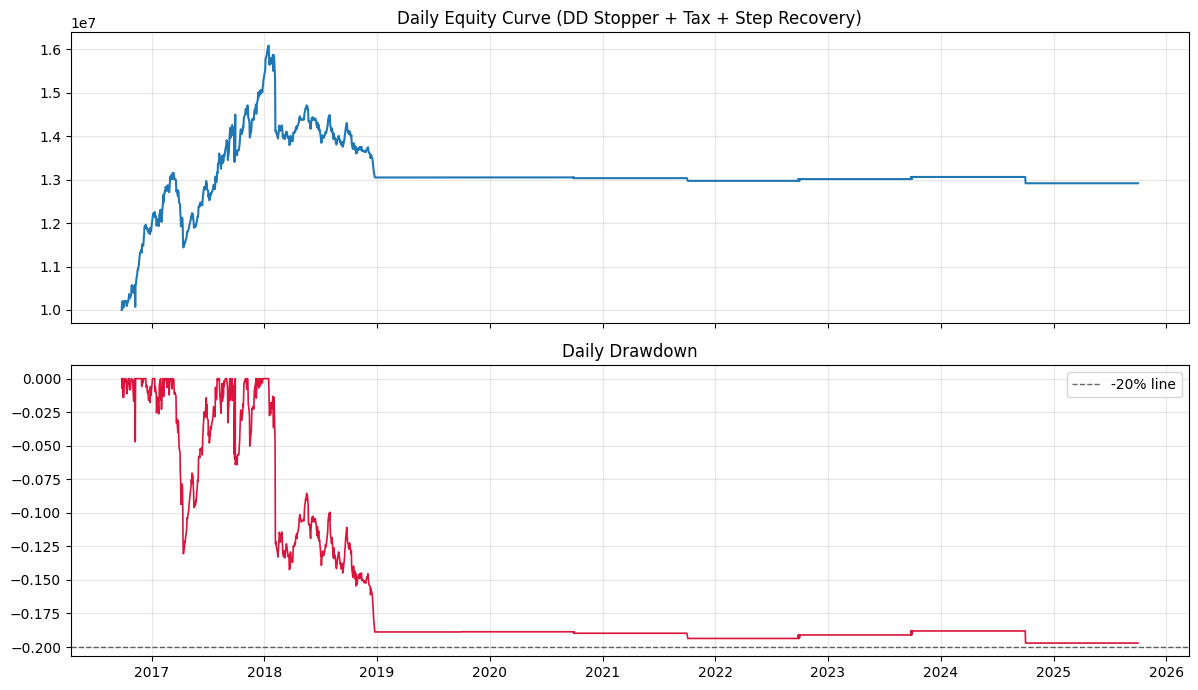

In [13]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
import os
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

warnings.filterwarnings('ignore')

# ===================================
# ロギング設定
# ===================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('backtest_long_only_october_unit_constraints.log', encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# ===================================
# グローバル変数
# ===================================
CACHE_FILE = 'topix_quarterly_statements.csv'
TAX_RATE = 0.20315
UNIT_SHARES = 100

# ===================================
# DDストッパー設定（下げる側：ハード制約）
# ===================================
DD_LVL1 = -0.10
DD_LVL2 = -0.15
DD_LVL3 = -0.18  # ここで全キャッシュ（-20%割れ防止の安全側）

EXP_FULL = 1.00
EXP_MID1 = 0.50
EXP_MID2 = 0.25
EXP_CASH = 0.00

# ===================================
# 段階復帰設定（戻す側：CAGR最大化の主戦場）
# 例：ddが改善するほど上限expを引き上げる
# ===================================
REC_LVL1 = -0.16  # ここを超えたら最大0.25まで戻して良い
REC_LVL2 = -0.12  # 最大0.50
REC_LVL3 = -0.10  # 最大0.75
REC_LVL4 = -0.08  # 最大1.00（フル復帰）

REC_EXP1 = 0.25
REC_EXP2 = 0.50
REC_EXP3 = 0.75
REC_EXP4 = 1.00

# 近傍価格探索
MAX_SHIFT_DAYS = 5

# 出力ファイル
DAILY_EQUITY_OUT = "daily_equity_curve_ddstop_tax_step_recover.csv"
REBALANCE_LOG_OUT = "rebalance_log_ddstop_tax_step_recover.csv"
PLOT_OUT = "equity_dd_ddstop_tax_step_recover.png"


# ===================================
# DD→投資比率（下げる側）
# ===================================
def exposure_from_dd(dd: float) -> float:
    """
    ddに応じて「最大許容エクスポージャー」を返す（下げは即時）
    """
    if dd <= DD_LVL3:
        return EXP_CASH
    elif dd <= DD_LVL2:
        return EXP_MID2
    elif dd <= DD_LVL1:
        return EXP_MID1
    else:
        return EXP_FULL

# ===================================
# 段階復帰：dd改善度合いに応じた「復帰上限」
# ===================================
def recovery_cap_from_dd(dd: float) -> float:
    """
    ddが回復していくほど、expの上限（cap）を上げる
    これにより、反発初動を少しずつ拾いながら、税・売買のジャンプを減らす
    """
    if dd >= REC_LVL4:
        return REC_EXP4  # 1.00
    elif dd >= REC_LVL3:
        return REC_EXP3  # 0.75
    elif dd >= REC_LVL2:
        return REC_EXP2  # 0.50
    elif dd >= REC_LVL1:
        return REC_EXP1  # 0.25
    else:
        return 0.0

def apply_step_recovery(current_exp: float, dd: float) -> float:
    """
    current_expを、復帰上限capまで引き上げて良い（ただし急に戻しすぎない）
    今回は「capまで一気に上げてOK」にしているが、さらに滑らかにするなら
    capへ近づける速度制限（例：日次+0.10まで）も追加可能。
    """
    cap = recovery_cap_from_dd(dd)
    return min(max(current_exp, cap), 1.0)


# ===================================
# A. 財務データ読み込み（列名自動判定版）
# ===================================
def load_financial_data(cache_filename: str = CACHE_FILE) -> pd.DataFrame:
    if not os.path.exists(cache_filename):
        logger.error(f"財務データファイル '{cache_filename}' が見つかりません")
        return pd.DataFrame()

    try:
        df = pd.read_csv(
            cache_filename,
            encoding='utf-8-sig',
            parse_dates=['DisclosedDate'],
            low_memory=False
        )
        logger.info(f"財務データ読み込み成功: {len(df):,}件")

        column_mapping = {
            'IssuedShareTotal': ['IssuedShareTotal', 'NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock'],
            'Equity': ['Equity', 'NetAssets', 'TotalEquity'],
            'Profit': ['Profit', 'NetIncome', 'ProfitAttributableToOwnersOfParent']
        }

        available_cols = df.columns.tolist()
        required_columns = {}

        for target_col, possible_names in column_mapping.items():
            found = False
            for possible_name in possible_names:
                if possible_name in available_cols:
                    required_columns[target_col] = possible_name
                    found = True
                    break
            if not found:
                required_columns[target_col] = None

        rename_dict = {v: k for k, v in required_columns.items() if v is not None}
        df = df.rename(columns=rename_dict)

        for col in ['IssuedShareTotal', 'Equity', 'Profit']:
            if col not in df.columns:
                df[col] = 0

        base_cols = ['Code', 'DisclosedDate']
        if 'CompanyName' in df.columns:
            base_cols.append('CompanyName')

        final_cols = base_cols + ['Profit', 'Equity', 'IssuedShareTotal']
        df = df[final_cols].copy()

        logger.info(f"使用列: {df.columns.tolist()}")
        return df

    except Exception as e:
        logger.error(f"財務データ読み込みエラー: {e}", exc_info=True)
        return pd.DataFrame()


# ===================================
# B. 株価データ読み込み（メモリ効率化版）
# ===================================
def load_existing_price_data(ohlcv_dir: str = './OHLCV_Adjusted') -> pd.DataFrame:
    if not os.path.exists(ohlcv_dir):
        logger.error(f"株価データディレクトリ '{ohlcv_dir}' が見つかりません。")
        return pd.DataFrame()

    csv_files = sorted([
        f for f in os.listdir(ohlcv_dir)
        if f.startswith('OHLCV_Adjusted_') and f.endswith('.csv') and f != 'OHLCV_Adjusted_TOPIX.csv'
    ])

    if not csv_files:
        logger.error(f"ディレクトリ '{ohlcv_dir}' 内にCSVファイルが見つかりません。")
        return pd.DataFrame()

    logger.info(f"株価ファイル数: {len(csv_files)}個")

    all_dataframes = []
    usecols = ['Date', 'Ticker', 'AdjustmentClose']

    for csv_file in tqdm(csv_files, desc="株価ファイル読み込み中"):
        file_path = os.path.join(ohlcv_dir, csv_file)
        try:
            df = pd.read_csv(
                file_path,
                usecols=usecols,
                parse_dates=['Date'],
                dtype={'Ticker': 'Int64', 'AdjustmentClose': 'float32'}
            )
            df = df.drop_duplicates(subset=['Ticker', 'Date'], keep='first')
            all_dataframes.append(df)
        except Exception as e:
            logger.warning(f"ファイル読み込みエラー ({csv_file}): {e}")
            continue

    if not all_dataframes:
        return pd.DataFrame()

    logger.info("全ファイルを結合中...")
    df_all = pd.concat(all_dataframes, ignore_index=True)
    logger.info(f"結合完了: {len(df_all):,}件")

    df_all = df_all.rename(columns={'Ticker': 'Code', 'AdjustmentClose': 'Close'})
    df_all['Code'] = df_all['Code'].astype(str).str.replace('<NA>', '0').str.zfill(4)
    df_all = df_all.dropna(subset=['Close'])

    logger.info("重複除去 & ソート中...")
    df_all = df_all.sort_values(['Code', 'Date'])
    df_all = df_all.drop_duplicates(subset=['Code', 'Date'], keep='first')
    logger.info(f"重複除去後: {len(df_all):,}件")

    return df_all


# ===================================
# C. 財務指標計算（チャンク処理版）
# ===================================
def safe_code_to_int(code_series: pd.Series) -> pd.Series:
    cleaned = code_series.astype(str).str.replace(r'\D', '', regex=True)
    cleaned = cleaned.replace('', '0')
    return pd.to_numeric(cleaned, errors='coerce').fillna(0).astype('int64')

def calculate_market_metrics_fast_chunked(statements_df: pd.DataFrame,
                                          prices_df: pd.DataFrame,
                                          chunk_size: int = 200) -> pd.DataFrame:
    logger.info("時価総額・PBR・ROE計算中（チャンク処理版）...")

    if prices_df.empty:
        logger.error("株価データが空です。")
        return pd.DataFrame()

    statements_df = statements_df.copy()
    prices_df = prices_df.copy()

    statements_df['Profit'] = pd.to_numeric(statements_df['Profit'], errors='coerce').fillna(0)
    statements_df['Equity'] = pd.to_numeric(statements_df['Equity'], errors='coerce').fillna(0)
    statements_df['IssuedShareTotal'] = pd.to_numeric(statements_df['IssuedShareTotal'], errors='coerce').fillna(1)

    statements_df = statements_df[(statements_df['Equity'] > 0) & (statements_df['IssuedShareTotal'] > 0)]
    logger.info(f"有効な財務データ: {len(statements_df):,}件")

    logger.info("Code列を整数型に変換中...")
    statements_df['Code_int'] = safe_code_to_int(statements_df['Code'])
    prices_df['Code_int'] = safe_code_to_int(prices_df['Code'])

    statements_df = statements_df[statements_df['Code_int'] > 0]
    prices_df = prices_df[prices_df['Code_int'] > 0]

    statements_df = statements_df.sort_values(['Code_int', 'DisclosedDate']).reset_index(drop=True)
    prices_df = prices_df.sort_values(['Code_int', 'Date']).reset_index(drop=True)

    statements_df = statements_df.drop_duplicates(subset=['Code_int', 'DisclosedDate'], keep='first')
    prices_df = prices_df.drop_duplicates(subset=['Code_int', 'Date'], keep='first')

    logger.info(f"ソート・重複除去後: 財務 {len(statements_df):,}件, 株価 {len(prices_df):,}件")
    logger.info("銘柄ごとにマージ中...")

    statements_groups = list(statements_df.groupby('Code_int'))
    prices_dict = {code: group for code, group in prices_df.groupby('Code_int')}

    merged_list = []
    num_chunks = (len(statements_groups) + chunk_size - 1) // chunk_size

    for chunk_idx in tqdm(range(num_chunks), desc="マージ処理"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, len(statements_groups))
        chunk_groups = statements_groups[start_idx:end_idx]

        for code, stmt_code in chunk_groups:
            if code not in prices_dict:
                continue
            price_code = prices_dict[code]
            if len(price_code) == 0:
                continue

            stmt_code = stmt_code.sort_values('DisclosedDate').reset_index(drop=True)
            price_code = price_code.sort_values('Date').reset_index(drop=True)

            try:
                merged = pd.merge_asof(
                    stmt_code,
                    price_code[['Date', 'Close']],
                    left_on='DisclosedDate',
                    right_on='Date',
                    direction='backward',
                    tolerance=pd.Timedelta(days=10)
                )
                if not merged.empty:
                    merged_list.append(merged)
            except Exception:
                continue

    if not merged_list:
        logger.error("マージ結果が空です")
        return pd.DataFrame()

    df_merged = pd.concat(merged_list, ignore_index=True).dropna(subset=['Close'])
    logger.info(f"マージ完了: {len(df_merged):,}件")

    df_merged['MarketCap'] = df_merged['Close'] * df_merged['IssuedShareTotal']
    df_merged['PBR'] = df_merged['MarketCap'] / df_merged['Equity']
    df_merged['ROE'] = (df_merged['Profit'] / df_merged['Equity']) * 100

    result_cols = ['Code', 'DisclosedDate', 'Close', 'MarketCap', 'PBR', 'ROE', 'Date']
    if 'CompanyName' in df_merged.columns:
        result_cols.insert(1, 'CompanyName')

    result_df = df_merged[result_cols].copy()
    result_df = result_df.rename(columns={'Close': 'StockPrice', 'Date': 'PriceDate'})

    mask = (
        (result_df['PBR'] > 0) &
        (result_df['PBR'] < 50) &
        (result_df['ROE'] > -100) &
        (result_df['ROE'] < 100) &
        (result_df['MarketCap'] > 1_000_000_000)
    )
    result_df = result_df[mask].copy()

    logger.info(f"計算完了: {len(result_df):,}件")
    return result_df


# ===================================
# D. ポートフォリオ構築（100株単位）
# ===================================
def build_unit_share_portfolio(stock_candidates: pd.DataFrame,
                               target_positions: int = 20,
                               initial_capital: float = 10_000_000) -> dict:
    if len(stock_candidates) == 0:
        return {'stocks': [], 'shares': [], 'prices': [], 'amounts': []}

    selected = stock_candidates.head(target_positions).copy()
    capital_per_stock = initial_capital / len(selected)

    stocks, shares_list, prices_list, amounts_list = [], [], [], []
    for _, row in selected.iterrows():
        code = row['Code']
        price = float(row['StockPrice'])
        required_amount = price * UNIT_SHARES
        if required_amount <= capital_per_stock:
            shares = int(capital_per_stock // required_amount) * UNIT_SHARES
            if shares > 0:
                stocks.append(code)
                shares_list.append(int(shares))
                prices_list.append(price)
                amounts_list.append(shares * price)

    return {'stocks': stocks, 'shares': shares_list, 'prices': prices_list, 'amounts': amounts_list}


# ===================================
# E. 日次評価のための価格アクセス
# ===================================
def make_price_pivot(prices_df: pd.DataFrame) -> pd.DataFrame:
    px = prices_df[['Date', 'Code', 'Close']].copy()
    px['Date'] = pd.to_datetime(px['Date'])
    px = px.sort_values(['Date', 'Code'])
    return px.pivot(index='Date', columns='Code', values='Close').sort_index()

def get_nearest_price(pivot: pd.DataFrame, date: pd.Timestamp, code: str, max_shift_days: int = 5) -> float:
    if date in pivot.index and code in pivot.columns:
        v = pivot.at[date, code]
        if pd.notna(v):
            return float(v)

    for k in range(1, max_shift_days + 1):
        d1 = date - pd.Timedelta(days=k)
        d2 = date + pd.Timedelta(days=k)
        if d1 in pivot.index and code in pivot.columns:
            v = pivot.at[d1, code]
            if pd.notna(v):
                return float(v)
        if d2 in pivot.index and code in pivot.columns:
            v = pivot.at[d2, code]
            if pd.notna(v):
                return float(v)
    return np.nan


# ===================================
# 税付き売買（DDストッパー用）
# ===================================
def sell_to_target_value(holdings: dict, cost_basis: dict, pivot: pd.DataFrame,
                         date: pd.Timestamp, target_value: float, cash: float) -> tuple:
    items = []
    total_value = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if not np.isfinite(px) or sh <= 0:
            continue
        v = sh * px
        total_value += v
        items.append((code, sh, px, v))

    if total_value <= target_value:
        return holdings, cost_basis, cash, 0.0, 0.0

    need_sell_value = total_value - target_value
    items.sort(key=lambda x: x[3], reverse=True)

    tax_paid = 0.0
    realized_profit = 0.0

    for code, sh, px, v in items:
        if need_sell_value <= 0:
            break

        max_sell_value = sh * px
        sell_value = min(max_sell_value, need_sell_value)

        sell_shares = int((sell_value / px) // UNIT_SHARES) * UNIT_SHARES
        sell_shares = min(sell_shares, sh)

        if sell_shares <= 0:
            continue

        proceeds = sell_shares * px
        cb = float(cost_basis.get(code, px))
        profit = (px - cb) * sell_shares
        profit = max(profit, 0.0)  # 損失は課税なし（損益通算なし簡易）

        tax = profit * TAX_RATE

        cash += proceeds - tax
        tax_paid += tax
        realized_profit += profit

        holdings[code] = sh - sell_shares
        if holdings[code] <= 0:
            holdings.pop(code, None)
            cost_basis.pop(code, None)

        need_sell_value -= proceeds

    return holdings, cost_basis, cash, tax_paid, realized_profit


def buy_to_target_value(holdings: dict, cost_basis: dict, pivot: pd.DataFrame,
                        date: pd.Timestamp, target_value: float, cash: float) -> tuple:
    items = []
    total_value = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if not np.isfinite(px) or sh <= 0:
            continue
        v = sh * px
        total_value += v
        items.append((code, sh, px, v))

    if total_value >= target_value:
        return holdings, cost_basis, cash, 0.0

    need_buy_value = target_value - total_value
    buy_budget = min(cash, need_buy_value)
    if buy_budget <= 0 or len(items) == 0:
        return holdings, cost_basis, cash, 0.0

    buy_value_total = 0.0
    for code, sh, px, v in items:
        if buy_budget <= 0:
            break

        w = v / total_value if total_value > 0 else 1.0 / len(items)
        alloc = buy_budget * w

        buy_shares = int((alloc / px) // UNIT_SHARES) * UNIT_SHARES
        if buy_shares <= 0:
            continue

        cost = buy_shares * px
        if cost > cash:
            continue

        old_sh = holdings.get(code, 0)
        old_cb = float(cost_basis.get(code, px))
        new_sh = old_sh + buy_shares
        new_cb = (old_sh * old_cb + buy_shares * px) / new_sh

        holdings[code] = new_sh
        cost_basis[code] = new_cb

        cash -= cost
        buy_value_total += cost

    return holdings, cost_basis, cash, buy_value_total


def compute_stock_value(holdings: dict, pivot: pd.DataFrame, date: pd.Timestamp) -> float:
    v = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if np.isfinite(px):
            v += sh * px
    return v


# ===================================
# F. バックテスト（年次10/1選定 + 日次DDストッパー + 税あり + 段階復帰）
# ===================================
def smbc_value_quality_backtest_october_unit_daily_ddstop_tax_step_recover(
    enhanced_financial_data: pd.DataFrame,
    prices_df: pd.DataFrame,
    initial_capital: float = 10_000_000
) -> dict:

    logger.info(f"10月1日リバランス + 日次DDストッパー（税あり・段階復帰）実行中（初期資本{initial_capital:,.0f}円）...")

    rebalance_dates = [pd.Timestamp(f'{year}-10-01') for year in range(2016, 2026)]
    logger.info(f"リバランス日数: {len(rebalance_dates)}回")
    logger.info(f"リバランス日: {[d.strftime('%Y-%m-%d') for d in rebalance_dates]}")

    logger.info("日次時価評価のため価格ピボット作成中...")
    pivot = make_price_pivot(prices_df)
    all_dates = pivot.index.sort_values()

    cash = float(initial_capital)
    holdings = {}
    cost_basis = {}

    peak = float(initial_capital)
    exp = 1.0  # 現在の目標エクスポージャー（段階復帰で上げ下げ）

    daily_rows = []
    rebalance_rows = []
    total_tax_paid = 0.0
    total_realized_profit = 0.0

    for i in range(len(rebalance_dates) - 1):
        reb_date = rebalance_dates[i]
        next_reb = rebalance_dates[i+1]

        # reb_dateを営業日に寄せる
        if reb_date not in all_dates:
            cand = all_dates[(all_dates >= reb_date - pd.Timedelta(days=MAX_SHIFT_DAYS)) &
                             (all_dates <= reb_date + pd.Timedelta(days=MAX_SHIFT_DAYS))]
            if len(cand) == 0:
                continue
            reb_exec = cand[0]
        else:
            reb_exec = reb_date

        # ===== 銘柄選定 =====
        current_data = enhanced_financial_data[enhanced_financial_data['DisclosedDate'] <= reb_date].copy()
        current_data = current_data.sort_values('DisclosedDate').groupby('Code').tail(1)
        if len(current_data) < 100:
            logger.warning(f"{reb_date}: データ不足（{len(current_data)}銘柄）")
            continue

        current_data['PBR_Rank'] = current_data['PBR'].rank(method='first', ascending=True)
        current_data['ROE_Rank'] = current_data['ROE'].rank(method='first', ascending=False)

        current_data['PBR_Quartile'] = pd.qcut(current_data['PBR_Rank'], q=4, labels=[1,2,3,4])
        current_data['ROE_Quartile'] = pd.qcut(current_data['ROE_Rank'], q=4, labels=[1,2,3,4])

        long_candidates = current_data[
            (current_data['PBR_Quartile'] == 1) &
            (current_data['ROE_Quartile'] == 4)
        ].nsmallest(50, 'PBR')

        # ===== 年次リバランス：全売却→税→買い直し =====
        tax_paid = 0.0
        realized_profit = 0.0

        if len(holdings) > 0:
            holdings, cost_basis, cash, tax_paid, realized_profit = sell_to_target_value(
                holdings, cost_basis, pivot, reb_exec, target_value=0.0, cash=cash
            )
            total_tax_paid += tax_paid
            total_realized_profit += realized_profit

        equity = cash

        new_portfolio = build_unit_share_portfolio(long_candidates, target_positions=20, initial_capital=equity)
        logger.info(f"{reb_date.strftime('%Y-%m')}: {len(new_portfolio['stocks'])}銘柄選定、投資額{sum(new_portfolio['amounts']):,.0f}円")

        holdings = {}
        cost_basis = {}
        invest_amount = 0.0

        for j, code in enumerate(new_portfolio['stocks']):
            sh = int(new_portfolio['shares'][j])
            px = get_nearest_price(pivot, reb_exec, code, MAX_SHIFT_DAYS)
            if not np.isfinite(px):
                continue
            cost = sh * px
            if cost > cash:
                continue
            cash -= cost
            invest_amount += cost
            holdings[code] = holdings.get(code, 0) + sh
            cost_basis[code] = px

        stock_value = compute_stock_value(holdings, pivot, reb_exec)
        equity = cash + stock_value

        rebalance_rows.append({
            "rebalance_date": reb_date,
            "rebalance_exec_date": reb_exec,
            "next_rebalance": next_reb,
            "n_stocks": len(holdings),
            "stock_value": stock_value,
            "cash": cash,
            "equity": equity,
            "investment_ratio": (stock_value / equity) if equity > 0 else 0.0,
            "tax_paid_yen": tax_paid,
            "realized_profit_yen": realized_profit
        })

        # ===== 日次運用 =====
        eval_dates = all_dates[(all_dates >= reb_exec) & (all_dates <= next_reb)]
        if len(eval_dates) < 2:
            continue

        # 初日記録
        stock_value0 = compute_stock_value(holdings, pivot, eval_dates[0])
        equity0 = cash + stock_value0
        peak = max(peak, equity0)

        daily_rows.append({
            "Date": eval_dates[0],
            "equity": equity0,
            "cash": cash,
            "stock_value": stock_value0,
            "peak": peak,
            "dd": equity0 / peak - 1.0 if peak > 0 else 0.0,
            "exp": stock_value0 / equity0 if equity0 > 0 else 0.0,
            "tax_paid_yen": 0.0,
            "realized_profit_yen": 0.0,
            "event": "rebalance"
        })

        for t in range(1, len(eval_dates)):
            d = eval_dates[t]

            # まず時価評価
            stock_value = compute_stock_value(holdings, pivot, d)
            equity = cash + stock_value

            # DD計算
            peak = max(peak, equity)
            dd = equity / peak - 1.0 if peak > 0 else 0.0

            # (1) 下げ側：ddに応じて「最大許容exp」を計算し、即時に落とす
            down_cap = exposure_from_dd(dd)
            exp = min(exp, down_cap)

            # (2) 戻し側：dd改善に応じた段階復帰（capに引き上げ）
            exp = apply_step_recovery(exp, dd)

            # 目標株式時価
            target_stock_value = exp * equity

            tax_paid_d = 0.0
            realized_profit_d = 0.0
            event = "hold"

            # 売買（税あり）
            if stock_value > target_stock_value + 1e-9:
                holdings, cost_basis, cash, tax_paid_d, realized_profit_d = sell_to_target_value(
                    holdings, cost_basis, pivot, d, target_value=target_stock_value, cash=cash
                )
                total_tax_paid += tax_paid_d
                total_realized_profit += realized_profit_d
                event = "sell_ddstop"
            elif stock_value < target_stock_value - 1e-9:
                holdings, cost_basis, cash, buy_value = buy_to_target_value(
                    holdings, cost_basis, pivot, d, target_value=target_stock_value, cash=cash
                )
                event = "buy_ddstop" if buy_value > 0 else "hold"

            # 再評価
            stock_value = compute_stock_value(holdings, pivot, d)
            equity = cash + stock_value
            peak = max(peak, equity)
            dd = equity / peak - 1.0 if peak > 0 else 0.0

            daily_rows.append({
                "Date": d,
                "equity": equity,
                "cash": cash,
                "stock_value": stock_value,
                "peak": peak,
                "dd": dd,
                "exp": stock_value / equity if equity > 0 else 0.0,
                "tax_paid_yen": tax_paid_d,
                "realized_profit_yen": realized_profit_d,
                "event": event
            })

    daily_df = pd.DataFrame(daily_rows).sort_values("Date").reset_index(drop=True)
    rebalance_df = pd.DataFrame(rebalance_rows)

    if not daily_df.empty:
        daily_df["equity_cummax"] = daily_df["equity"].cummax()
        daily_df["drawdown"] = daily_df["equity"] / daily_df["equity_cummax"] - 1.0
        mdd_daily = float(daily_df["drawdown"].min())
    else:
        mdd_daily = np.nan

    return {
        "daily": daily_df,
        "rebalance": rebalance_df,
        "mdd_daily": mdd_daily,
        "total_tax_paid_yen": float(total_tax_paid),
        "total_realized_profit_yen": float(total_realized_profit)
    }


# ===================================
# 日次系列からパフォーマンス
# ===================================
def perf_stats_from_daily_equity(daily_df: pd.DataFrame) -> dict:
    if daily_df.empty:
        return {}

    d = daily_df.copy().sort_values("Date").reset_index(drop=True)
    d["ret"] = d["equity"].pct_change().fillna(0.0)

    n = len(d)
    eq_end = float(d["equity"].iloc[-1])
    eq_start = float(d["equity"].iloc[0])

    years = (d["Date"].iloc[-1] - d["Date"].iloc[0]).days / 365.25 if n >= 2 else np.nan
    cagr = (eq_end / eq_start) ** (1.0 / years) - 1.0 if years and years > 0 else np.nan

    vol = float(d["ret"].std(ddof=1) * np.sqrt(252))
    mean = float(d["ret"].mean() * 252)
    sharpe = mean / vol if vol > 0 else np.nan

    d["cummax"] = d["equity"].cummax()
    d["dd2"] = d["equity"] / d["cummax"] - 1.0
    mdd = float(d["dd2"].min())

    calmar = cagr / abs(mdd) if (mdd < 0 and np.isfinite(cagr)) else np.nan

    return {
        "CAGR": float(cagr),
        "vol_ann": vol,
        "sharpe_ann": float(sharpe),
        "maxDD": mdd,
        "calmar": float(calmar),
        "start": str(d["Date"].iloc[0].date()),
        "end": str(d["Date"].iloc[-1].date()),
        "n_days": int(n),
        "equity_end": eq_end
    }


# ===================================
# 図
# ===================================
def plot_equity_and_dd(daily_df: pd.DataFrame, out_png: str = PLOT_OUT):
    if daily_df.empty:
        return

    d = daily_df.copy().sort_values("Date")
    d["cummax"] = d["equity"].cummax()
    d["dd2"] = d["equity"] / d["cummax"] - 1.0

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(d["Date"], d["equity"], linewidth=1.5)
    ax[0].set_title("Daily Equity Curve (DD Stopper + Tax + Step Recovery)")
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(d["Date"], d["dd2"], color="crimson", linewidth=1.2)
    ax[1].axhline(-0.20, color="black", linestyle="--", linewidth=1.0, alpha=0.6, label="-20% line")
    ax[1].set_title("Daily Drawdown")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[1].xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    logger.info(f"図を保存: {out_png}")


# ===================================
# メイン
# ===================================
if __name__ == "__main__":
    print("=" * 80)
    print("🏆 SMBC「割安高質」戦略 - 10月1日リバランス（100株単位） + DDストッパー（日次・税あり・段階復帰）")
    print("=" * 80)
    print(f"  DD下げ: {DD_LVL1},{DD_LVL2},{DD_LVL3} / exp={EXP_FULL},{EXP_MID1},{EXP_MID2},{EXP_CASH}")
    print(f"  段階復帰: {REC_LVL1},{REC_LVL2},{REC_LVL3},{REC_LVL4} / cap={REC_EXP1},{REC_EXP2},{REC_EXP3},{REC_EXP4}")
    print(f"  税: {TAX_RATE*100:.3f}%（DD売買にも課税） / 現金利回り0%")
    print(f"  実行日時: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

    statements_df = load_financial_data()
    if statements_df.empty:
        logger.error("財務データ読み込み失敗")
        raise SystemExit(1)

    prices_df = load_existing_price_data()
    if prices_df.empty:
        logger.error("株価データ読み込み失敗")
        raise SystemExit(1)

    enhanced_financial_data = calculate_market_metrics_fast_chunked(statements_df, prices_df, chunk_size=200)
    if enhanced_financial_data.empty:
        logger.error("財務指標計算失敗")
        raise SystemExit(1)

    result = smbc_value_quality_backtest_october_unit_daily_ddstop_tax_step_recover(
        enhanced_financial_data, prices_df, initial_capital=10_000_000
    )

    daily_df = result["daily"]
    reb_df = result["rebalance"]

    if daily_df.empty:
        logger.error("日次結果が空です")
        raise SystemExit(1)

    stats = perf_stats_from_daily_equity(daily_df)

    print("\n" + "=" * 80)
    print("📊 日次ベース・パフォーマンス（段階復帰）")
    print("=" * 80)
    print(f"  期間: {stats['start']} 〜 {stats['end']}  (n={stats['n_days']})")
    print(f"  CAGR:   {stats['CAGR']*100:8.2f}%")
    print(f"  vol :   {stats['vol_ann']*100:8.2f}%")
    print(f"  Sharpe: {stats['sharpe_ann']:8.3f}")
    print(f"  maxDD:  {stats['maxDD']*100:8.2f}%")
    print(f"  Calmar: {stats['calmar']:8.3f}")
    print(f"  Total tax paid (yen): {result['total_tax_paid_yen']:,.0f}")
    print(f"  Total realized profit (yen): {result['total_realized_profit_yen']:,.0f}")

    daily_df.to_csv(DAILY_EQUITY_OUT, index=False, encoding="utf-8-sig")
    reb_df.to_csv(REBALANCE_LOG_OUT, index=False, encoding="utf-8-sig")
    logger.info(f"日次エクイティ曲線を保存: {DAILY_EQUITY_OUT}")
    logger.info(f"リバランスログを保存: {REBALANCE_LOG_OUT}")

    plot_equity_and_dd(daily_df, out_png=PLOT_OUT)

    print("\n" + "=" * 80)
    print("✅ 段階復帰版バックテスト完了")
    print("=" * 80)
    print(f"📁 出力ファイル:")
    print(f"  - 日次エクイティ: {DAILY_EQUITY_OUT}")
    print(f"  - リバランスログ: {REBALANCE_LOG_OUT}")
    print(f"  - 図: {PLOT_OUT}")
    print("\n")


🏆 SMBC「割安高質」戦略 - 10月1日リバランス（100株単位） + DDストッパー（日次・税あり・段階復帰・NoTrade）
  No-Trade Band: 2.0%
  税: 20.315%（DD売買にも課税） / 現金利回り0%
  実行日時: 2026-01-29 04:46:27


2026-01-29 04:46:28,579 - INFO - 財務データ読み込み成功: 64,222件
2026-01-29 04:46:28,611 - INFO - 使用列: ['Code', 'DisclosedDate', 'CompanyName', 'Profit', 'Equity', 'IssuedShareTotal']
2026-01-29 04:46:28,614 - INFO - 株価ファイル数: 50個
株価ファイル読み込み中: 100%|██████████| 50/50 [00:13<00:00,  3.80it/s]
2026-01-29 04:46:41,790 - INFO - 全ファイルを結合中...
2026-01-29 04:46:41,838 - INFO - 結合完了: 9,929,369件
2026-01-29 04:46:46,841 - INFO - 重複除去 & ソート中...
2026-01-29 04:46:51,165 - INFO - 重複除去後: 9,606,444件
2026-01-29 04:46:52,039 - INFO - 時価総額・PBR・ROE計算中（チャンク処理版）...
2026-01-29 04:46:52,240 - INFO - 有効な財務データ: 62,741件
2026-01-29 04:46:52,241 - INFO - Code列を整数型に変換中...
2026-01-29 04:47:24,532 - INFO - ソート・重複除去後: 財務 62,463件, 株価 9,605,995件
2026-01-29 04:47:24,534 - INFO - 銘柄ごとにマージ中...
マージ処理: 100%|██████████| 9/9 [00:07<00:00,  1.14it/s]
2026-01-29 04:47:34,838 - INFO - マージ完了: 62,360件
2026-01-29 04:47:34,870 - INFO - 計算完了: 62,108件
2026-01-29 04:47:35,290 - INFO - 10月1日リバランス + 日次DDストッパー（税あり・段階復帰・NoTrade）実行中（初期資本10,000,000円）...
20


📊 日次ベース・パフォーマンス（段階復帰＋NoTrade）
  期間: 2016-09-26 〜 2025-10-01  (n=2223)
  CAGR:       2.98%
  vol :       9.00%
  Sharpe:    0.378
  maxDD:    -18.86%
  Calmar:    0.158
  Total tax paid (yen): 1,678,884
  Total realized profit (yen): 8,264,259


2026-01-29 04:47:43,423 - INFO - 図を保存: equity_dd_ddstop_tax_step_recover_notrade02.png



✅ No-Trade Band 追加版バックテスト完了
📁 出力ファイル:
  - 日次エクイティ: daily_equity_curve_ddstop_tax_step_recover_notrade02.csv
  - リバランスログ: rebalance_log_ddstop_tax_step_recover_notrade02.csv
  - 図: equity_dd_ddstop_tax_step_recover_notrade02.png




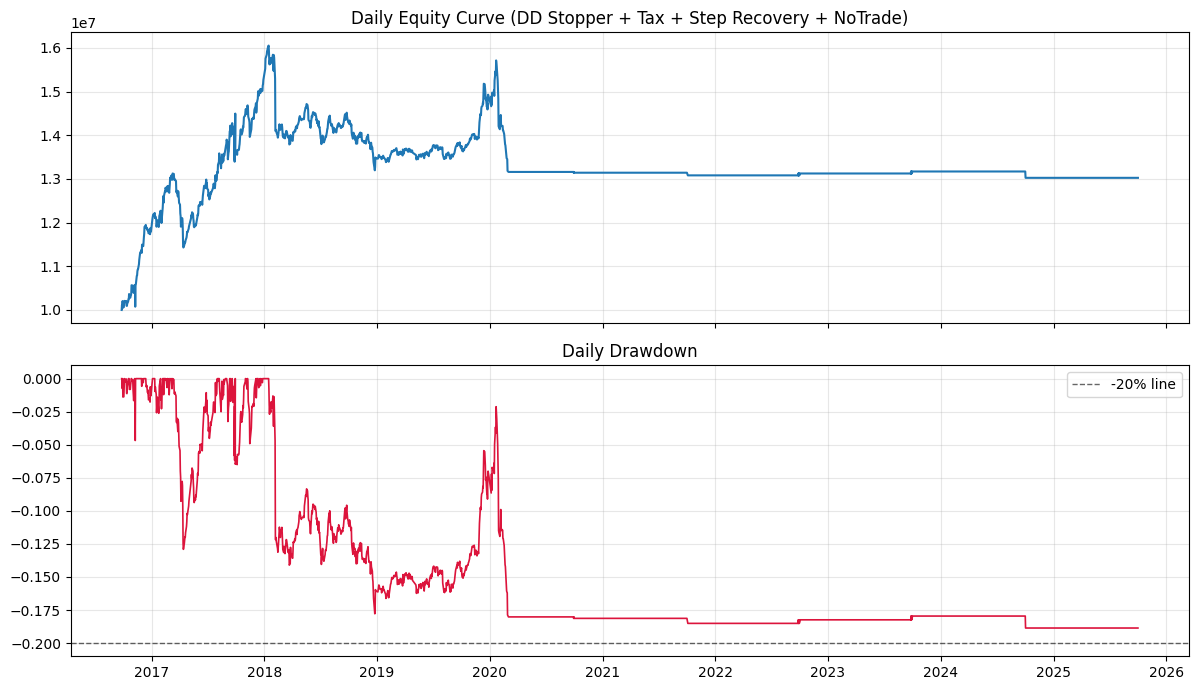

In [14]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
import os
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

warnings.filterwarnings('ignore')

# ===================================
# ロギング設定
# ===================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('backtest_long_only_october_unit_constraints.log', encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# ===================================
# グローバル変数
# ===================================
CACHE_FILE = 'topix_quarterly_statements.csv'
TAX_RATE = 0.20315
UNIT_SHARES = 100

# ===================================
# DDストッパー設定（下げる側：ハード制約）
# ===================================
DD_LVL1 = -0.10
DD_LVL2 = -0.15
DD_LVL3 = -0.18  # ここで全キャッシュ（-20%割れ防止の安全側）

EXP_FULL = 1.00
EXP_MID1 = 0.50
EXP_MID2 = 0.25
EXP_CASH = 0.00

# ===================================
# 段階復帰設定（戻す側）
# ===================================
REC_LVL1 = -0.16  # cap 0.25
REC_LVL2 = -0.12  # cap 0.50
REC_LVL3 = -0.10  # cap 0.75
REC_LVL4 = -0.08  # cap 1.00

REC_EXP1 = 0.25
REC_EXP2 = 0.50
REC_EXP3 = 0.75
REC_EXP4 = 1.00

# ===================================
# NEW: No-Trade Band（売買しない帯域）
# ===================================
NO_TRADE_BAND = 0.02  # equityの±2%以内の調整はスキップ

# 近傍価格探索
MAX_SHIFT_DAYS = 5

# 出力ファイル
DAILY_EQUITY_OUT = "daily_equity_curve_ddstop_tax_step_recover_notrade02.csv"
REBALANCE_LOG_OUT = "rebalance_log_ddstop_tax_step_recover_notrade02.csv"
PLOT_OUT = "equity_dd_ddstop_tax_step_recover_notrade02.png"


# ===================================
# DD→投資比率（下げる側）
# ===================================
def exposure_from_dd(dd: float) -> float:
    if dd <= DD_LVL3:
        return EXP_CASH
    elif dd <= DD_LVL2:
        return EXP_MID2
    elif dd <= DD_LVL1:
        return EXP_MID1
    else:
        return EXP_FULL

# ===================================
# 段階復帰：dd改善度合いに応じた「復帰上限」
# ===================================
def recovery_cap_from_dd(dd: float) -> float:
    if dd >= REC_LVL4:
        return REC_EXP4
    elif dd >= REC_LVL3:
        return REC_EXP3
    elif dd >= REC_LVL2:
        return REC_EXP2
    elif dd >= REC_LVL1:
        return REC_EXP1
    else:
        return 0.0

def apply_step_recovery(current_exp: float, dd: float) -> float:
    cap = recovery_cap_from_dd(dd)
    return min(max(current_exp, cap), 1.0)


# ===================================
# A. 財務データ読み込み（列名自動判定版）
# ===================================
def load_financial_data(cache_filename: str = CACHE_FILE) -> pd.DataFrame:
    if not os.path.exists(cache_filename):
        logger.error(f"財務データファイル '{cache_filename}' が見つかりません")
        return pd.DataFrame()

    try:
        df = pd.read_csv(
            cache_filename,
            encoding='utf-8-sig',
            parse_dates=['DisclosedDate'],
            low_memory=False
        )
        logger.info(f"財務データ読み込み成功: {len(df):,}件")

        column_mapping = {
            'IssuedShareTotal': ['IssuedShareTotal', 'NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock'],
            'Equity': ['Equity', 'NetAssets', 'TotalEquity'],
            'Profit': ['Profit', 'NetIncome', 'ProfitAttributableToOwnersOfParent']
        }

        available_cols = df.columns.tolist()
        required_columns = {}

        for target_col, possible_names in column_mapping.items():
            found = False
            for possible_name in possible_names:
                if possible_name in available_cols:
                    required_columns[target_col] = possible_name
                    found = True
                    break
            if not found:
                required_columns[target_col] = None

        rename_dict = {v: k for k, v in required_columns.items() if v is not None}
        df = df.rename(columns=rename_dict)

        for col in ['IssuedShareTotal', 'Equity', 'Profit']:
            if col not in df.columns:
                df[col] = 0

        base_cols = ['Code', 'DisclosedDate']
        if 'CompanyName' in df.columns:
            base_cols.append('CompanyName')

        final_cols = base_cols + ['Profit', 'Equity', 'IssuedShareTotal']
        df = df[final_cols].copy()

        logger.info(f"使用列: {df.columns.tolist()}")
        return df

    except Exception as e:
        logger.error(f"財務データ読み込みエラー: {e}", exc_info=True)
        return pd.DataFrame()


# ===================================
# B. 株価データ読み込み（メモリ効率化版）
# ===================================
def load_existing_price_data(ohlcv_dir: str = './OHLCV_Adjusted') -> pd.DataFrame:
    if not os.path.exists(ohlcv_dir):
        logger.error(f"株価データディレクトリ '{ohlcv_dir}' が見つかりません。")
        return pd.DataFrame()

    csv_files = sorted([
        f for f in os.listdir(ohlcv_dir)
        if f.startswith('OHLCV_Adjusted_') and f.endswith('.csv') and f != 'OHLCV_Adjusted_TOPIX.csv'
    ])

    if not csv_files:
        logger.error(f"ディレクトリ '{ohlcv_dir}' 内にCSVファイルが見つかりません。")
        return pd.DataFrame()

    logger.info(f"株価ファイル数: {len(csv_files)}個")

    all_dataframes = []
    usecols = ['Date', 'Ticker', 'AdjustmentClose']

    for csv_file in tqdm(csv_files, desc="株価ファイル読み込み中"):
        file_path = os.path.join(ohlcv_dir, csv_file)
        try:
            df = pd.read_csv(
                file_path,
                usecols=usecols,
                parse_dates=['Date'],
                dtype={'Ticker': 'Int64', 'AdjustmentClose': 'float32'}
            )
            df = df.drop_duplicates(subset=['Ticker', 'Date'], keep='first')
            all_dataframes.append(df)
        except Exception as e:
            logger.warning(f"ファイル読み込みエラー ({csv_file}): {e}")
            continue

    if not all_dataframes:
        return pd.DataFrame()

    logger.info("全ファイルを結合中...")
    df_all = pd.concat(all_dataframes, ignore_index=True)
    logger.info(f"結合完了: {len(df_all):,}件")

    df_all = df_all.rename(columns={'Ticker': 'Code', 'AdjustmentClose': 'Close'})
    df_all['Code'] = df_all['Code'].astype(str).str.replace('<NA>', '0').str.zfill(4)
    df_all = df_all.dropna(subset=['Close'])

    logger.info("重複除去 & ソート中...")
    df_all = df_all.sort_values(['Code', 'Date'])
    df_all = df_all.drop_duplicates(subset=['Code', 'Date'], keep='first')
    logger.info(f"重複除去後: {len(df_all):,}件")

    return df_all


# ===================================
# C. 財務指標計算（チャンク処理版）
# ===================================
def safe_code_to_int(code_series: pd.Series) -> pd.Series:
    cleaned = code_series.astype(str).str.replace(r'\D', '', regex=True)
    cleaned = cleaned.replace('', '0')
    return pd.to_numeric(cleaned, errors='coerce').fillna(0).astype('int64')

def calculate_market_metrics_fast_chunked(statements_df: pd.DataFrame,
                                          prices_df: pd.DataFrame,
                                          chunk_size: int = 200) -> pd.DataFrame:
    logger.info("時価総額・PBR・ROE計算中（チャンク処理版）...")

    if prices_df.empty:
        logger.error("株価データが空です。")
        return pd.DataFrame()

    statements_df = statements_df.copy()
    prices_df = prices_df.copy()

    statements_df['Profit'] = pd.to_numeric(statements_df['Profit'], errors='coerce').fillna(0)
    statements_df['Equity'] = pd.to_numeric(statements_df['Equity'], errors='coerce').fillna(0)
    statements_df['IssuedShareTotal'] = pd.to_numeric(statements_df['IssuedShareTotal'], errors='coerce').fillna(1)

    statements_df = statements_df[(statements_df['Equity'] > 0) & (statements_df['IssuedShareTotal'] > 0)]
    logger.info(f"有効な財務データ: {len(statements_df):,}件")

    logger.info("Code列を整数型に変換中...")
    statements_df['Code_int'] = safe_code_to_int(statements_df['Code'])
    prices_df['Code_int'] = safe_code_to_int(prices_df['Code'])

    statements_df = statements_df[statements_df['Code_int'] > 0]
    prices_df = prices_df[prices_df['Code_int'] > 0]

    statements_df = statements_df.sort_values(['Code_int', 'DisclosedDate']).reset_index(drop=True)
    prices_df = prices_df.sort_values(['Code_int', 'Date']).reset_index(drop=True)

    statements_df = statements_df.drop_duplicates(subset=['Code_int', 'DisclosedDate'], keep='first')
    prices_df = prices_df.drop_duplicates(subset=['Code_int', 'Date'], keep='first')

    logger.info(f"ソート・重複除去後: 財務 {len(statements_df):,}件, 株価 {len(prices_df):,}件")
    logger.info("銘柄ごとにマージ中...")

    statements_groups = list(statements_df.groupby('Code_int'))
    prices_dict = {code: group for code, group in prices_df.groupby('Code_int')}

    merged_list = []
    num_chunks = (len(statements_groups) + chunk_size - 1) // chunk_size

    for chunk_idx in tqdm(range(num_chunks), desc="マージ処理"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, len(statements_groups))
        chunk_groups = statements_groups[start_idx:end_idx]

        for code, stmt_code in chunk_groups:
            if code not in prices_dict:
                continue
            price_code = prices_dict[code]
            if len(price_code) == 0:
                continue

            stmt_code = stmt_code.sort_values('DisclosedDate').reset_index(drop=True)
            price_code = price_code.sort_values('Date').reset_index(drop=True)

            try:
                merged = pd.merge_asof(
                    stmt_code,
                    price_code[['Date', 'Close']],
                    left_on='DisclosedDate',
                    right_on='Date',
                    direction='backward',
                    tolerance=pd.Timedelta(days=10)
                )
                if not merged.empty:
                    merged_list.append(merged)
            except Exception:
                continue

    if not merged_list:
        logger.error("マージ結果が空です")
        return pd.DataFrame()

    df_merged = pd.concat(merged_list, ignore_index=True).dropna(subset=['Close'])
    logger.info(f"マージ完了: {len(df_merged):,}件")

    df_merged['MarketCap'] = df_merged['Close'] * df_merged['IssuedShareTotal']
    df_merged['PBR'] = df_merged['MarketCap'] / df_merged['Equity']
    df_merged['ROE'] = (df_merged['Profit'] / df_merged['Equity']) * 100

    result_cols = ['Code', 'DisclosedDate', 'Close', 'MarketCap', 'PBR', 'ROE', 'Date']
    if 'CompanyName' in df_merged.columns:
        result_cols.insert(1, 'CompanyName')

    result_df = df_merged[result_cols].copy()
    result_df = result_df.rename(columns={'Close': 'StockPrice', 'Date': 'PriceDate'})

    mask = (
        (result_df['PBR'] > 0) &
        (result_df['PBR'] < 50) &
        (result_df['ROE'] > -100) &
        (result_df['ROE'] < 100) &
        (result_df['MarketCap'] > 1_000_000_000)
    )
    result_df = result_df[mask].copy()

    logger.info(f"計算完了: {len(result_df):,}件")
    return result_df


# ===================================
# D. ポートフォリオ構築（100株単位）
# ===================================
def build_unit_share_portfolio(stock_candidates: pd.DataFrame,
                               target_positions: int = 20,
                               initial_capital: float = 10_000_000) -> dict:
    if len(stock_candidates) == 0:
        return {'stocks': [], 'shares': [], 'prices': [], 'amounts': []}

    selected = stock_candidates.head(target_positions).copy()
    capital_per_stock = initial_capital / len(selected)

    stocks, shares_list, prices_list, amounts_list = [], [], [], []
    for _, row in selected.iterrows():
        code = row['Code']
        price = float(row['StockPrice'])
        required_amount = price * UNIT_SHARES
        if required_amount <= capital_per_stock:
            shares = int(capital_per_stock // required_amount) * UNIT_SHARES
            if shares > 0:
                stocks.append(code)
                shares_list.append(int(shares))
                prices_list.append(price)
                amounts_list.append(shares * price)

    return {'stocks': stocks, 'shares': shares_list, 'prices': prices_list, 'amounts': amounts_list}


# ===================================
# E. 日次評価のための価格アクセス
# ===================================
def make_price_pivot(prices_df: pd.DataFrame) -> pd.DataFrame:
    px = prices_df[['Date', 'Code', 'Close']].copy()
    px['Date'] = pd.to_datetime(px['Date'])
    px = px.sort_values(['Date', 'Code'])
    return px.pivot(index='Date', columns='Code', values='Close').sort_index()

def get_nearest_price(pivot: pd.DataFrame, date: pd.Timestamp, code: str, max_shift_days: int = 5) -> float:
    if date in pivot.index and code in pivot.columns:
        v = pivot.at[date, code]
        if pd.notna(v):
            return float(v)

    for k in range(1, max_shift_days + 1):
        d1 = date - pd.Timedelta(days=k)
        d2 = date + pd.Timedelta(days=k)
        if d1 in pivot.index and code in pivot.columns:
            v = pivot.at[d1, code]
            if pd.notna(v):
                return float(v)
        if d2 in pivot.index and code in pivot.columns:
            v = pivot.at[d2, code]
            if pd.notna(v):
                return float(v)
    return np.nan


# ===================================
# 税付き売買（DDストッパー用）
# ===================================
def sell_to_target_value(holdings: dict, cost_basis: dict, pivot: pd.DataFrame,
                         date: pd.Timestamp, target_value: float, cash: float) -> tuple:
    items = []
    total_value = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if not np.isfinite(px) or sh <= 0:
            continue
        v = sh * px
        total_value += v
        items.append((code, sh, px, v))

    if total_value <= target_value:
        return holdings, cost_basis, cash, 0.0, 0.0

    need_sell_value = total_value - target_value
    items.sort(key=lambda x: x[3], reverse=True)

    tax_paid = 0.0
    realized_profit = 0.0

    for code, sh, px, v in items:
        if need_sell_value <= 0:
            break

        max_sell_value = sh * px
        sell_value = min(max_sell_value, need_sell_value)

        sell_shares = int((sell_value / px) // UNIT_SHARES) * UNIT_SHARES
        sell_shares = min(sell_shares, sh)

        if sell_shares <= 0:
            continue

        proceeds = sell_shares * px
        cb = float(cost_basis.get(code, px))
        profit = (px - cb) * sell_shares
        profit = max(profit, 0.0)

        tax = profit * TAX_RATE

        cash += proceeds - tax
        tax_paid += tax
        realized_profit += profit

        holdings[code] = sh - sell_shares
        if holdings[code] <= 0:
            holdings.pop(code, None)
            cost_basis.pop(code, None)

        need_sell_value -= proceeds

    return holdings, cost_basis, cash, tax_paid, realized_profit


def buy_to_target_value(holdings: dict, cost_basis: dict, pivot: pd.DataFrame,
                        date: pd.Timestamp, target_value: float, cash: float) -> tuple:
    items = []
    total_value = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if not np.isfinite(px) or sh <= 0:
            continue
        v = sh * px
        total_value += v
        items.append((code, sh, px, v))

    if total_value >= target_value:
        return holdings, cost_basis, cash, 0.0

    need_buy_value = target_value - total_value
    buy_budget = min(cash, need_buy_value)
    if buy_budget <= 0 or len(items) == 0:
        return holdings, cost_basis, cash, 0.0

    buy_value_total = 0.0
    for code, sh, px, v in items:
        if buy_budget <= 0:
            break

        w = v / total_value if total_value > 0 else 1.0 / len(items)
        alloc = buy_budget * w

        buy_shares = int((alloc / px) // UNIT_SHARES) * UNIT_SHARES
        if buy_shares <= 0:
            continue

        cost = buy_shares * px
        if cost > cash:
            continue

        old_sh = holdings.get(code, 0)
        old_cb = float(cost_basis.get(code, px))
        new_sh = old_sh + buy_shares
        new_cb = (old_sh * old_cb + buy_shares * px) / new_sh

        holdings[code] = new_sh
        cost_basis[code] = new_cb

        cash -= cost
        buy_value_total += cost

    return holdings, cost_basis, cash, buy_value_total


def compute_stock_value(holdings: dict, pivot: pd.DataFrame, date: pd.Timestamp) -> float:
    v = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if np.isfinite(px):
            v += sh * px
    return v


# ===================================
# F. バックテスト（年次10/1選定 + 日次DDストッパー + 税あり + 段階復帰 + No-Trade）
# ===================================
def smbc_value_quality_backtest_october_unit_daily_ddstop_tax_step_recover_notrade(
    enhanced_financial_data: pd.DataFrame,
    prices_df: pd.DataFrame,
    initial_capital: float = 10_000_000
) -> dict:

    logger.info(f"10月1日リバランス + 日次DDストッパー（税あり・段階復帰・NoTrade）実行中（初期資本{initial_capital:,.0f}円）...")

    rebalance_dates = [pd.Timestamp(f'{year}-10-01') for year in range(2016, 2026)]
    logger.info(f"リバランス日数: {len(rebalance_dates)}回")
    logger.info(f"リバランス日: {[d.strftime('%Y-%m-%d') for d in rebalance_dates]}")

    logger.info("日次時価評価のため価格ピボット作成中...")
    pivot = make_price_pivot(prices_df)
    all_dates = pivot.index.sort_values()

    cash = float(initial_capital)
    holdings = {}
    cost_basis = {}

    peak = float(initial_capital)
    exp = 1.0

    daily_rows = []
    rebalance_rows = []
    total_tax_paid = 0.0
    total_realized_profit = 0.0

    for i in range(len(rebalance_dates) - 1):
        reb_date = rebalance_dates[i]
        next_reb = rebalance_dates[i+1]

        # reb_dateを営業日に寄せる
        if reb_date not in all_dates:
            cand = all_dates[(all_dates >= reb_date - pd.Timedelta(days=MAX_SHIFT_DAYS)) &
                             (all_dates <= reb_date + pd.Timedelta(days=MAX_SHIFT_DAYS))]
            if len(cand) == 0:
                continue
            reb_exec = cand[0]
        else:
            reb_exec = reb_date

        # ===== 銘柄選定 =====
        current_data = enhanced_financial_data[enhanced_financial_data['DisclosedDate'] <= reb_date].copy()
        current_data = current_data.sort_values('DisclosedDate').groupby('Code').tail(1)
        if len(current_data) < 100:
            logger.warning(f"{reb_date}: データ不足（{len(current_data)}銘柄）")
            continue

        current_data['PBR_Rank'] = current_data['PBR'].rank(method='first', ascending=True)
        current_data['ROE_Rank'] = current_data['ROE'].rank(method='first', ascending=False)

        current_data['PBR_Quartile'] = pd.qcut(current_data['PBR_Rank'], q=4, labels=[1,2,3,4])
        current_data['ROE_Quartile'] = pd.qcut(current_data['ROE_Rank'], q=4, labels=[1,2,3,4])

        long_candidates = current_data[
            (current_data['PBR_Quartile'] == 1) &
            (current_data['ROE_Quartile'] == 4)
        ].nsmallest(50, 'PBR')

        # ===== 年次リバランス：全売却→税→買い直し =====
        tax_paid = 0.0
        realized_profit = 0.0

        if len(holdings) > 0:
            holdings, cost_basis, cash, tax_paid, realized_profit = sell_to_target_value(
                holdings, cost_basis, pivot, reb_exec, target_value=0.0, cash=cash
            )
            total_tax_paid += tax_paid
            total_realized_profit += realized_profit

        equity = cash

        new_portfolio = build_unit_share_portfolio(long_candidates, target_positions=20, initial_capital=equity)
        logger.info(f"{reb_date.strftime('%Y-%m')}: {len(new_portfolio['stocks'])}銘柄選定、投資額{sum(new_portfolio['amounts']):,.0f}円")

        holdings = {}
        cost_basis = {}
        invest_amount = 0.0

        for j, code in enumerate(new_portfolio['stocks']):
            sh = int(new_portfolio['shares'][j])
            px = get_nearest_price(pivot, reb_exec, code, MAX_SHIFT_DAYS)
            if not np.isfinite(px):
                continue
            cost = sh * px
            if cost > cash:
                continue
            cash -= cost
            invest_amount += cost
            holdings[code] = holdings.get(code, 0) + sh
            cost_basis[code] = px

        stock_value = compute_stock_value(holdings, pivot, reb_exec)
        equity = cash + stock_value

        rebalance_rows.append({
            "rebalance_date": reb_date,
            "rebalance_exec_date": reb_exec,
            "next_rebalance": next_reb,
            "n_stocks": len(holdings),
            "stock_value": stock_value,
            "cash": cash,
            "equity": equity,
            "investment_ratio": (stock_value / equity) if equity > 0 else 0.0,
            "tax_paid_yen": tax_paid,
            "realized_profit_yen": realized_profit
        })

        # ===== 日次運用 =====
        eval_dates = all_dates[(all_dates >= reb_exec) & (all_dates <= next_reb)]
        if len(eval_dates) < 2:
            continue

        # 初日
        stock_value0 = compute_stock_value(holdings, pivot, eval_dates[0])
        equity0 = cash + stock_value0
        peak = max(peak, equity0)

        daily_rows.append({
            "Date": eval_dates[0],
            "equity": equity0,
            "cash": cash,
            "stock_value": stock_value0,
            "peak": peak,
            "dd": equity0 / peak - 1.0 if peak > 0 else 0.0,
            "exp": stock_value0 / equity0 if equity0 > 0 else 0.0,
            "tax_paid_yen": 0.0,
            "realized_profit_yen": 0.0,
            "event": "rebalance",
            "gap": 0.0
        })

        for t in range(1, len(eval_dates)):
            d = eval_dates[t]

            # 時価評価
            stock_value = compute_stock_value(holdings, pivot, d)
            equity = cash + stock_value

            # DD計算
            peak = max(peak, equity)
            dd = equity / peak - 1.0 if peak > 0 else 0.0

            # 下げ：即時
            down_cap = exposure_from_dd(dd)
            exp = min(exp, down_cap)

            # 戻し：段階復帰
            exp = apply_step_recovery(exp, dd)

            target_stock_value = exp * equity

            # NEW: No-Trade Band判定
            gap = abs(stock_value - target_stock_value) / equity if equity > 0 else 0.0

            tax_paid_d = 0.0
            realized_profit_d = 0.0
            event = "hold"

            if gap < NO_TRADE_BAND:
                # 売買しない
                event = "no_trade_band"
            else:
                # 売買（税あり）
                if stock_value > target_stock_value + 1e-9:
                    holdings, cost_basis, cash, tax_paid_d, realized_profit_d = sell_to_target_value(
                        holdings, cost_basis, pivot, d, target_value=target_stock_value, cash=cash
                    )
                    total_tax_paid += tax_paid_d
                    total_realized_profit += realized_profit_d
                    event = "sell_ddstop"
                elif stock_value < target_stock_value - 1e-9:
                    holdings, cost_basis, cash, buy_value = buy_to_target_value(
                        holdings, cost_basis, pivot, d, target_value=target_stock_value, cash=cash
                    )
                    event = "buy_ddstop" if buy_value > 0 else "hold"

            # 再評価
            stock_value = compute_stock_value(holdings, pivot, d)
            equity = cash + stock_value
            peak = max(peak, equity)
            dd = equity / peak - 1.0 if peak > 0 else 0.0

            daily_rows.append({
                "Date": d,
                "equity": equity,
                "cash": cash,
                "stock_value": stock_value,
                "peak": peak,
                "dd": dd,
                "exp": stock_value / equity if equity > 0 else 0.0,
                "tax_paid_yen": tax_paid_d,
                "realized_profit_yen": realized_profit_d,
                "event": event,
                "gap": gap
            })

    daily_df = pd.DataFrame(daily_rows).sort_values("Date").reset_index(drop=True)
    rebalance_df = pd.DataFrame(rebalance_rows)

    if not daily_df.empty:
        daily_df["equity_cummax"] = daily_df["equity"].cummax()
        daily_df["drawdown"] = daily_df["equity"] / daily_df["equity_cummax"] - 1.0
        mdd_daily = float(daily_df["drawdown"].min())
    else:
        mdd_daily = np.nan

    return {
        "daily": daily_df,
        "rebalance": rebalance_df,
        "mdd_daily": mdd_daily,
        "total_tax_paid_yen": float(total_tax_paid),
        "total_realized_profit_yen": float(total_realized_profit)
    }


# ===================================
# 日次系列からパフォーマンス
# ===================================
def perf_stats_from_daily_equity(daily_df: pd.DataFrame) -> dict:
    if daily_df.empty:
        return {}

    d = daily_df.copy().sort_values("Date").reset_index(drop=True)
    d["ret"] = d["equity"].pct_change().fillna(0.0)

    n = len(d)
    eq_end = float(d["equity"].iloc[-1])
    eq_start = float(d["equity"].iloc[0])

    years = (d["Date"].iloc[-1] - d["Date"].iloc[0]).days / 365.25 if n >= 2 else np.nan
    cagr = (eq_end / eq_start) ** (1.0 / years) - 1.0 if years and years > 0 else np.nan

    vol = float(d["ret"].std(ddof=1) * np.sqrt(252))
    mean = float(d["ret"].mean() * 252)
    sharpe = mean / vol if vol > 0 else np.nan

    d["cummax"] = d["equity"].cummax()
    d["dd2"] = d["equity"] / d["cummax"] - 1.0
    mdd = float(d["dd2"].min())

    calmar = cagr / abs(mdd) if (mdd < 0 and np.isfinite(cagr)) else np.nan

    return {
        "CAGR": float(cagr),
        "vol_ann": vol,
        "sharpe_ann": float(sharpe),
        "maxDD": mdd,
        "calmar": float(calmar),
        "start": str(d["Date"].iloc[0].date()),
        "end": str(d["Date"].iloc[-1].date()),
        "n_days": int(n),
        "equity_end": eq_end
    }


# ===================================
# 図
# ===================================
def plot_equity_and_dd(daily_df: pd.DataFrame, out_png: str = PLOT_OUT):
    if daily_df.empty:
        return

    d = daily_df.copy().sort_values("Date")
    d["cummax"] = d["equity"].cummax()
    d["dd2"] = d["equity"] / d["cummax"] - 1.0

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(d["Date"], d["equity"], linewidth=1.5)
    ax[0].set_title("Daily Equity Curve (DD Stopper + Tax + Step Recovery + NoTrade)")
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(d["Date"], d["dd2"], color="crimson", linewidth=1.2)
    ax[1].axhline(-0.20, color="black", linestyle="--", linewidth=1.0, alpha=0.6, label="-20% line")
    ax[1].set_title("Daily Drawdown")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[1].xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    logger.info(f"図を保存: {out_png}")


# ===================================
# メイン
# ===================================
if __name__ == "__main__":
    print("=" * 80)
    print("🏆 SMBC「割安高質」戦略 - 10月1日リバランス（100株単位） + DDストッパー（日次・税あり・段階復帰・NoTrade）")
    print("=" * 80)
    print(f"  No-Trade Band: {NO_TRADE_BAND*100:.1f}%")
    print(f"  税: {TAX_RATE*100:.3f}%（DD売買にも課税） / 現金利回り0%")
    print(f"  実行日時: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

    statements_df = load_financial_data()
    if statements_df.empty:
        logger.error("財務データ読み込み失敗")
        raise SystemExit(1)

    prices_df = load_existing_price_data()
    if prices_df.empty:
        logger.error("株価データ読み込み失敗")
        raise SystemExit(1)

    enhanced_financial_data = calculate_market_metrics_fast_chunked(statements_df, prices_df, chunk_size=200)
    if enhanced_financial_data.empty:
        logger.error("財務指標計算失敗")
        raise SystemExit(1)

    result = smbc_value_quality_backtest_october_unit_daily_ddstop_tax_step_recover_notrade(
        enhanced_financial_data, prices_df, initial_capital=10_000_000
    )

    daily_df = result["daily"]
    reb_df = result["rebalance"]

    if daily_df.empty:
        logger.error("日次結果が空です")
        raise SystemExit(1)

    stats = perf_stats_from_daily_equity(daily_df)

    print("\n" + "=" * 80)
    print("📊 日次ベース・パフォーマンス（段階復帰＋NoTrade）")
    print("=" * 80)
    print(f"  期間: {stats['start']} 〜 {stats['end']}  (n={stats['n_days']})")
    print(f"  CAGR:   {stats['CAGR']*100:8.2f}%")
    print(f"  vol :   {stats['vol_ann']*100:8.2f}%")
    print(f"  Sharpe: {stats['sharpe_ann']:8.3f}")
    print(f"  maxDD:  {stats['maxDD']*100:8.2f}%")
    print(f"  Calmar: {stats['calmar']:8.3f}")
    print(f"  Total tax paid (yen): {result['total_tax_paid_yen']:,.0f}")
    print(f"  Total realized profit (yen): {result['total_realized_profit_yen']:,.0f}")

    daily_df.to_csv(DAILY_EQUITY_OUT, index=False, encoding="utf-8-sig")
    reb_df.to_csv(REBALANCE_LOG_OUT, index=False, encoding="utf-8-sig")
    logger.info(f"日次エクイティ曲線を保存: {DAILY_EQUITY_OUT}")
    logger.info(f"リバランスログを保存: {REBALANCE_LOG_OUT}")

    plot_equity_and_dd(daily_df, out_png=PLOT_OUT)

    print("\n" + "=" * 80)
    print("✅ No-Trade Band 追加版バックテスト完了")
    print("=" * 80)
    print(f"📁 出力ファイル:")
    print(f"  - 日次エクイティ: {DAILY_EQUITY_OUT}")
    print(f"  - リバランスログ: {REBALANCE_LOG_OUT}")
    print(f"  - 図: {PLOT_OUT}")
    print("\n")


🏆 SMBC「割安高質」戦略 - DDストッパー（日次・税あり・段階復帰・NoTrade）: REC閾値を早める版
  No-Trade Band: 2.0%
  REC_LVL: -0.18, -0.14, -0.12, -0.1
  税: 20.315% / 現金利回り0%


2026-01-29 04:51:19,060 - INFO - 財務データ読み込み成功: 64,222件
2026-01-29 04:51:19,094 - INFO - 使用列: ['Code', 'DisclosedDate', 'CompanyName', 'Profit', 'Equity', 'IssuedShareTotal']
2026-01-29 04:51:19,097 - INFO - 株価ファイル数: 50個
株価ファイル読み込み中: 100%|██████████| 50/50 [00:09<00:00,  5.38it/s]
2026-01-29 04:51:28,399 - INFO - 全ファイルを結合中...
2026-01-29 04:51:28,440 - INFO - 結合完了: 9,929,369件
2026-01-29 04:51:34,575 - INFO - 重複除去 & ソート中...
2026-01-29 04:51:40,508 - INFO - 重複除去後: 9,606,444件
2026-01-29 04:51:41,239 - INFO - 時価総額・PBR・ROE計算中（チャンク処理版）...
2026-01-29 04:51:41,502 - INFO - 有効な財務データ: 62,741件
2026-01-29 04:51:41,503 - INFO - Code列を整数型に変換中...
2026-01-29 04:52:06,792 - INFO - ソート・重複除去後: 財務 62,463件, 株価 9,605,995件
2026-01-29 04:52:06,793 - INFO - 銘柄ごとにマージ中...
マージ処理: 100%|██████████| 9/9 [00:06<00:00,  1.47it/s]
2026-01-29 04:52:14,814 - INFO - マージ完了: 62,360件
2026-01-29 04:52:14,839 - INFO - 計算完了: 62,108件
2026-01-29 04:52:15,153 - INFO - 10月1日リバランス + 日次DDストッパー（税あり・段階復帰・NoTrade）実行中（初期資本10,000,000円）...
20


📊 日次ベース・パフォーマンス（REC早め版）
  期間: 2016-09-26 〜 2025-10-01  (n=2223)
  CAGR:       3.24%
  vol :       8.68%
  Sharpe:    0.418
  maxDD:    -19.10%
  Calmar:    0.170
  Total tax paid (yen): 1,390,386
  Total realized profit (yen): 6,844,134


2026-01-29 04:52:24,679 - INFO - 図を保存: equity_dd_ddstop_tax_step_recover_notrade02_RECFAST.png



Saved.


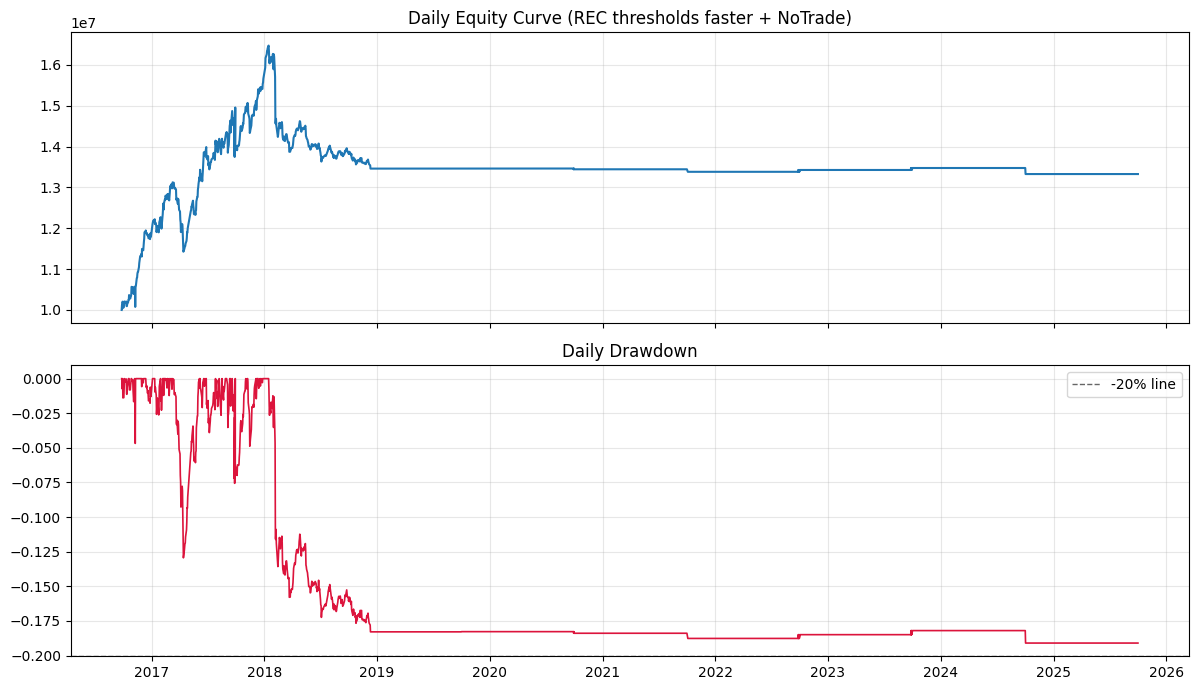

In [15]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
import os
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('backtest_long_only_october_unit_constraints.log', encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

CACHE_FILE = 'topix_quarterly_statements.csv'
TAX_RATE = 0.20315
UNIT_SHARES = 100

# ===================================
# DDストッパー（下げ側：ハード制約）
# ===================================
DD_LVL1 = -0.10
DD_LVL2 = -0.15
DD_LVL3 = -0.18

EXP_FULL = 1.00
EXP_MID1 = 0.50
EXP_MID2 = 0.25
EXP_CASH = 0.00

# ===================================
# 段階復帰（戻し側）: ★ここだけ「早める」
# ===================================
# 変更前:
# REC_LVL1 = -0.16
# REC_LVL2 = -0.12
# REC_LVL3 = -0.10
# REC_LVL4 = -0.08

# 変更後（復帰を早める）:
REC_LVL1 = -0.18  # cap 0.25
REC_LVL2 = -0.14  # cap 0.50
REC_LVL3 = -0.12  # cap 0.75
REC_LVL4 = -0.10  # cap 1.00

REC_EXP1 = 0.25
REC_EXP2 = 0.50
REC_EXP3 = 0.75
REC_EXP4 = 1.00

# No-Trade Band
NO_TRADE_BAND = 0.02

MAX_SHIFT_DAYS = 5

DAILY_EQUITY_OUT = "daily_equity_curve_ddstop_tax_step_recover_notrade02_RECFAST.csv"
REBALANCE_LOG_OUT = "rebalance_log_ddstop_tax_step_recover_notrade02_RECFAST.csv"
PLOT_OUT = "equity_dd_ddstop_tax_step_recover_notrade02_RECFAST.png"


def exposure_from_dd(dd: float) -> float:
    if dd <= DD_LVL3:
        return EXP_CASH
    elif dd <= DD_LVL2:
        return EXP_MID2
    elif dd <= DD_LVL1:
        return EXP_MID1
    else:
        return EXP_FULL


def recovery_cap_from_dd(dd: float) -> float:
    if dd >= REC_LVL4:
        return REC_EXP4
    elif dd >= REC_LVL3:
        return REC_EXP3
    elif dd >= REC_LVL2:
        return REC_EXP2
    elif dd >= REC_LVL1:
        return REC_EXP1
    else:
        return 0.0


def apply_step_recovery(current_exp: float, dd: float) -> float:
    cap = recovery_cap_from_dd(dd)
    return min(max(current_exp, cap), 1.0)


def load_financial_data(cache_filename: str = CACHE_FILE) -> pd.DataFrame:
    if not os.path.exists(cache_filename):
        logger.error(f"財務データファイル '{cache_filename}' が見つかりません")
        return pd.DataFrame()

    df = pd.read_csv(
        cache_filename,
        encoding='utf-8-sig',
        parse_dates=['DisclosedDate'],
        low_memory=False
    )
    logger.info(f"財務データ読み込み成功: {len(df):,}件")

    column_mapping = {
        'IssuedShareTotal': ['IssuedShareTotal', 'NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock'],
        'Equity': ['Equity', 'NetAssets', 'TotalEquity'],
        'Profit': ['Profit', 'NetIncome', 'ProfitAttributableToOwnersOfParent']
    }

    available_cols = df.columns.tolist()
    required_columns = {}

    for target_col, possible_names in column_mapping.items():
        found = False
        for possible_name in possible_names:
            if possible_name in available_cols:
                required_columns[target_col] = possible_name
                found = True
                break
        if not found:
            required_columns[target_col] = None

    rename_dict = {v: k for k, v in required_columns.items() if v is not None}
    df = df.rename(columns=rename_dict)

    for col in ['IssuedShareTotal', 'Equity', 'Profit']:
        if col not in df.columns:
            df[col] = 0

    base_cols = ['Code', 'DisclosedDate']
    if 'CompanyName' in df.columns:
        base_cols.append('CompanyName')

    final_cols = base_cols + ['Profit', 'Equity', 'IssuedShareTotal']
    df = df[final_cols].copy()

    logger.info(f"使用列: {df.columns.tolist()}")
    return df


def load_existing_price_data(ohlcv_dir: str = './OHLCV_Adjusted') -> pd.DataFrame:
    if not os.path.exists(ohlcv_dir):
        logger.error(f"株価データディレクトリ '{ohlcv_dir}' が見つかりません。")
        return pd.DataFrame()

    csv_files = sorted([
        f for f in os.listdir(ohlcv_dir)
        if f.startswith('OHLCV_Adjusted_') and f.endswith('.csv') and f != 'OHLCV_Adjusted_TOPIX.csv'
    ])

    if not csv_files:
        logger.error(f"ディレクトリ '{ohlcv_dir}' 内にCSVファイルが見つかりません。")
        return pd.DataFrame()

    logger.info(f"株価ファイル数: {len(csv_files)}個")

    all_dataframes = []
    usecols = ['Date', 'Ticker', 'AdjustmentClose']

    for csv_file in tqdm(csv_files, desc="株価ファイル読み込み中"):
        file_path = os.path.join(ohlcv_dir, csv_file)
        try:
            df = pd.read_csv(
                file_path,
                usecols=usecols,
                parse_dates=['Date'],
                dtype={'Ticker': 'Int64', 'AdjustmentClose': 'float32'}
            )
            df = df.drop_duplicates(subset=['Ticker', 'Date'], keep='first')
            all_dataframes.append(df)
        except Exception as e:
            logger.warning(f"ファイル読み込みエラー ({csv_file}): {e}")
            continue

    if not all_dataframes:
        return pd.DataFrame()

    logger.info("全ファイルを結合中...")
    df_all = pd.concat(all_dataframes, ignore_index=True)
    logger.info(f"結合完了: {len(df_all):,}件")

    df_all = df_all.rename(columns={'Ticker': 'Code', 'AdjustmentClose': 'Close'})
    df_all['Code'] = df_all['Code'].astype(str).str.replace('<NA>', '0').str.zfill(4)
    df_all = df_all.dropna(subset=['Close'])

    logger.info("重複除去 & ソート中...")
    df_all = df_all.sort_values(['Code', 'Date'])
    df_all = df_all.drop_duplicates(subset=['Code', 'Date'], keep='first')
    logger.info(f"重複除去後: {len(df_all):,}件")

    return df_all


def safe_code_to_int(code_series: pd.Series) -> pd.Series:
    cleaned = code_series.astype(str).str.replace(r'\D', '', regex=True)
    cleaned = cleaned.replace('', '0')
    return pd.to_numeric(cleaned, errors='coerce').fillna(0).astype('int64')


def calculate_market_metrics_fast_chunked(statements_df: pd.DataFrame,
                                          prices_df: pd.DataFrame,
                                          chunk_size: int = 200) -> pd.DataFrame:
    logger.info("時価総額・PBR・ROE計算中（チャンク処理版）...")

    if prices_df.empty:
        logger.error("株価データが空です。")
        return pd.DataFrame()

    statements_df = statements_df.copy()
    prices_df = prices_df.copy()

    statements_df['Profit'] = pd.to_numeric(statements_df['Profit'], errors='coerce').fillna(0)
    statements_df['Equity'] = pd.to_numeric(statements_df['Equity'], errors='coerce').fillna(0)
    statements_df['IssuedShareTotal'] = pd.to_numeric(statements_df['IssuedShareTotal'], errors='coerce').fillna(1)

    statements_df = statements_df[(statements_df['Equity'] > 0) & (statements_df['IssuedShareTotal'] > 0)]
    logger.info(f"有効な財務データ: {len(statements_df):,}件")

    logger.info("Code列を整数型に変換中...")
    statements_df['Code_int'] = safe_code_to_int(statements_df['Code'])
    prices_df['Code_int'] = safe_code_to_int(prices_df['Code'])

    statements_df = statements_df[statements_df['Code_int'] > 0]
    prices_df = prices_df[prices_df['Code_int'] > 0]

    statements_df = statements_df.sort_values(['Code_int', 'DisclosedDate']).reset_index(drop=True)
    prices_df = prices_df.sort_values(['Code_int', 'Date']).reset_index(drop=True)

    statements_df = statements_df.drop_duplicates(subset=['Code_int', 'DisclosedDate'], keep='first')
    prices_df = prices_df.drop_duplicates(subset=['Code_int', 'Date'], keep='first')

    logger.info(f"ソート・重複除去後: 財務 {len(statements_df):,}件, 株価 {len(prices_df):,}件")
    logger.info("銘柄ごとにマージ中...")

    statements_groups = list(statements_df.groupby('Code_int'))
    prices_dict = {code: group for code, group in prices_df.groupby('Code_int')}

    merged_list = []
    num_chunks = (len(statements_groups) + chunk_size - 1) // chunk_size

    for chunk_idx in tqdm(range(num_chunks), desc="マージ処理"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, len(statements_groups))
        chunk_groups = statements_groups[start_idx:end_idx]

        for code, stmt_code in chunk_groups:
            if code not in prices_dict:
                continue
            price_code = prices_dict[code]
            if len(price_code) == 0:
                continue

            stmt_code = stmt_code.sort_values('DisclosedDate').reset_index(drop=True)
            price_code = price_code.sort_values('Date').reset_index(drop=True)

            try:
                merged = pd.merge_asof(
                    stmt_code,
                    price_code[['Date', 'Close']],
                    left_on='DisclosedDate',
                    right_on='Date',
                    direction='backward',
                    tolerance=pd.Timedelta(days=10)
                )
                if not merged.empty:
                    merged_list.append(merged)
            except Exception:
                continue

    if not merged_list:
        logger.error("マージ結果が空です")
        return pd.DataFrame()

    df_merged = pd.concat(merged_list, ignore_index=True).dropna(subset=['Close'])
    logger.info(f"マージ完了: {len(df_merged):,}件")

    df_merged['MarketCap'] = df_merged['Close'] * df_merged['IssuedShareTotal']
    df_merged['PBR'] = df_merged['MarketCap'] / df_merged['Equity']
    df_merged['ROE'] = (df_merged['Profit'] / df_merged['Equity']) * 100

    result_cols = ['Code', 'DisclosedDate', 'Close', 'MarketCap', 'PBR', 'ROE', 'Date']
    if 'CompanyName' in df_merged.columns:
        result_cols.insert(1, 'CompanyName')

    result_df = df_merged[result_cols].copy()
    result_df = result_df.rename(columns={'Close': 'StockPrice', 'Date': 'PriceDate'})

    mask = (
        (result_df['PBR'] > 0) &
        (result_df['PBR'] < 50) &
        (result_df['ROE'] > -100) &
        (result_df['ROE'] < 100) &
        (result_df['MarketCap'] > 1_000_000_000)
    )
    result_df = result_df[mask].copy()

    logger.info(f"計算完了: {len(result_df):,}件")
    return result_df


def build_unit_share_portfolio(stock_candidates: pd.DataFrame,
                               target_positions: int = 20,
                               initial_capital: float = 10_000_000) -> dict:
    if len(stock_candidates) == 0:
        return {'stocks': [], 'shares': [], 'prices': [], 'amounts': []}

    selected = stock_candidates.head(target_positions).copy()
    capital_per_stock = initial_capital / len(selected)

    stocks, shares_list, prices_list, amounts_list = [], [], [], []
    for _, row in selected.iterrows():
        code = row['Code']
        price = float(row['StockPrice'])
        required_amount = price * UNIT_SHARES
        if required_amount <= capital_per_stock:
            shares = int(capital_per_stock // required_amount) * UNIT_SHARES
            if shares > 0:
                stocks.append(code)
                shares_list.append(int(shares))
                prices_list.append(price)
                amounts_list.append(shares * price)

    return {'stocks': stocks, 'shares': shares_list, 'prices': prices_list, 'amounts': amounts_list}


def make_price_pivot(prices_df: pd.DataFrame) -> pd.DataFrame:
    px = prices_df[['Date', 'Code', 'Close']].copy()
    px['Date'] = pd.to_datetime(px['Date'])
    px = px.sort_values(['Date', 'Code'])
    return px.pivot(index='Date', columns='Code', values='Close').sort_index()


def get_nearest_price(pivot: pd.DataFrame, date: pd.Timestamp, code: str, max_shift_days: int = 5) -> float:
    if date in pivot.index and code in pivot.columns:
        v = pivot.at[date, code]
        if pd.notna(v):
            return float(v)

    for k in range(1, max_shift_days + 1):
        d1 = date - pd.Timedelta(days=k)
        d2 = date + pd.Timedelta(days=k)
        if d1 in pivot.index and code in pivot.columns:
            v = pivot.at[d1, code]
            if pd.notna(v):
                return float(v)
        if d2 in pivot.index and code in pivot.columns:
            v = pivot.at[d2, code]
            if pd.notna(v):
                return float(v)
    return np.nan


def sell_to_target_value(holdings: dict, cost_basis: dict, pivot: pd.DataFrame,
                         date: pd.Timestamp, target_value: float, cash: float) -> tuple:
    items = []
    total_value = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if not np.isfinite(px) or sh <= 0:
            continue
        v = sh * px
        total_value += v
        items.append((code, sh, px, v))

    if total_value <= target_value:
        return holdings, cost_basis, cash, 0.0, 0.0

    need_sell_value = total_value - target_value
    items.sort(key=lambda x: x[3], reverse=True)

    tax_paid = 0.0
    realized_profit = 0.0

    for code, sh, px, v in items:
        if need_sell_value <= 0:
            break

        max_sell_value = sh * px
        sell_value = min(max_sell_value, need_sell_value)

        sell_shares = int((sell_value / px) // UNIT_SHARES) * UNIT_SHARES
        sell_shares = min(sell_shares, sh)

        if sell_shares <= 0:
            continue

        proceeds = sell_shares * px
        cb = float(cost_basis.get(code, px))
        profit = (px - cb) * sell_shares
        profit = max(profit, 0.0)

        tax = profit * TAX_RATE

        cash += proceeds - tax
        tax_paid += tax
        realized_profit += profit

        holdings[code] = sh - sell_shares
        if holdings[code] <= 0:
            holdings.pop(code, None)
            cost_basis.pop(code, None)

        need_sell_value -= proceeds

    return holdings, cost_basis, cash, tax_paid, realized_profit


def buy_to_target_value(holdings: dict, cost_basis: dict, pivot: pd.DataFrame,
                        date: pd.Timestamp, target_value: float, cash: float) -> tuple:
    items = []
    total_value = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if not np.isfinite(px) or sh <= 0:
            continue
        v = sh * px
        total_value += v
        items.append((code, sh, px, v))

    if total_value >= target_value:
        return holdings, cost_basis, cash, 0.0

    need_buy_value = target_value - total_value
    buy_budget = min(cash, need_buy_value)
    if buy_budget <= 0 or len(items) == 0:
        return holdings, cost_basis, cash, 0.0

    buy_value_total = 0.0
    for code, sh, px, v in items:
        if buy_budget <= 0:
            break

        w = v / total_value if total_value > 0 else 1.0 / len(items)
        alloc = buy_budget * w

        buy_shares = int((alloc / px) // UNIT_SHARES) * UNIT_SHARES
        if buy_shares <= 0:
            continue

        cost = buy_shares * px
        if cost > cash:
            continue

        old_sh = holdings.get(code, 0)
        old_cb = float(cost_basis.get(code, px))
        new_sh = old_sh + buy_shares
        new_cb = (old_sh * old_cb + buy_shares * px) / new_sh

        holdings[code] = new_sh
        cost_basis[code] = new_cb

        cash -= cost
        buy_value_total += cost

    return holdings, cost_basis, cash, buy_value_total


def compute_stock_value(holdings: dict, pivot: pd.DataFrame, date: pd.Timestamp) -> float:
    v = 0.0
    for code, sh in holdings.items():
        px = get_nearest_price(pivot, date, code, MAX_SHIFT_DAYS)
        if np.isfinite(px):
            v += sh * px
    return v


def smbc_value_quality_backtest_october_unit_daily_ddstop_tax_step_recover_notrade(
    enhanced_financial_data: pd.DataFrame,
    prices_df: pd.DataFrame,
    initial_capital: float = 10_000_000
) -> dict:

    logger.info(f"10月1日リバランス + 日次DDストッパー（税あり・段階復帰・NoTrade）実行中（初期資本{initial_capital:,.0f}円）...")

    rebalance_dates = [pd.Timestamp(f'{year}-10-01') for year in range(2016, 2026)]
    logger.info(f"リバランス日数: {len(rebalance_dates)}回")
    logger.info(f"リバランス日: {[d.strftime('%Y-%m-%d') for d in rebalance_dates]}")

    logger.info("日次時価評価のため価格ピボット作成中...")
    pivot = make_price_pivot(prices_df)
    all_dates = pivot.index.sort_values()

    cash = float(initial_capital)
    holdings = {}
    cost_basis = {}

    peak = float(initial_capital)
    exp = 1.0

    daily_rows = []
    rebalance_rows = []
    total_tax_paid = 0.0
    total_realized_profit = 0.0

    for i in range(len(rebalance_dates) - 1):
        reb_date = rebalance_dates[i]
        next_reb = rebalance_dates[i+1]

        if reb_date not in all_dates:
            cand = all_dates[(all_dates >= reb_date - pd.Timedelta(days=MAX_SHIFT_DAYS)) &
                             (all_dates <= reb_date + pd.Timedelta(days=MAX_SHIFT_DAYS))]
            if len(cand) == 0:
                continue
            reb_exec = cand[0]
        else:
            reb_exec = reb_date

        current_data = enhanced_financial_data[enhanced_financial_data['DisclosedDate'] <= reb_date].copy()
        current_data = current_data.sort_values('DisclosedDate').groupby('Code').tail(1)
        if len(current_data) < 100:
            logger.warning(f"{reb_date}: データ不足（{len(current_data)}銘柄）")
            continue

        current_data['PBR_Rank'] = current_data['PBR'].rank(method='first', ascending=True)
        current_data['ROE_Rank'] = current_data['ROE'].rank(method='first', ascending=False)

        current_data['PBR_Quartile'] = pd.qcut(current_data['PBR_Rank'], q=4, labels=[1,2,3,4])
        current_data['ROE_Quartile'] = pd.qcut(current_data['ROE_Rank'], q=4, labels=[1,2,3,4])

        long_candidates = current_data[
            (current_data['PBR_Quartile'] == 1) &
            (current_data['ROE_Quartile'] == 4)
        ].nsmallest(50, 'PBR')

        tax_paid = 0.0
        realized_profit = 0.0

        if len(holdings) > 0:
            holdings, cost_basis, cash, tax_paid, realized_profit = sell_to_target_value(
                holdings, cost_basis, pivot, reb_exec, target_value=0.0, cash=cash
            )
            total_tax_paid += tax_paid
            total_realized_profit += realized_profit

        equity = cash
        new_portfolio = build_unit_share_portfolio(long_candidates, target_positions=20, initial_capital=equity)

        logger.info(f"{reb_date.strftime('%Y-%m')}: {len(new_portfolio['stocks'])}銘柄選定、投資額{sum(new_portfolio['amounts']):,.0f}円")

        holdings = {}
        cost_basis = {}
        for j, code in enumerate(new_portfolio['stocks']):
            sh = int(new_portfolio['shares'][j])
            px = get_nearest_price(pivot, reb_exec, code, MAX_SHIFT_DAYS)
            if not np.isfinite(px):
                continue
            cost = sh * px
            if cost > cash:
                continue
            cash -= cost
            holdings[code] = holdings.get(code, 0) + sh
            cost_basis[code] = px

        stock_value = compute_stock_value(holdings, pivot, reb_exec)
        equity = cash + stock_value

        rebalance_rows.append({
            "rebalance_date": reb_date,
            "rebalance_exec_date": reb_exec,
            "next_rebalance": next_reb,
            "n_stocks": len(holdings),
            "stock_value": stock_value,
            "cash": cash,
            "equity": equity,
            "investment_ratio": (stock_value / equity) if equity > 0 else 0.0,
            "tax_paid_yen": tax_paid,
            "realized_profit_yen": realized_profit
        })

        eval_dates = all_dates[(all_dates >= reb_exec) & (all_dates <= next_reb)]
        if len(eval_dates) < 2:
            continue

        stock_value0 = compute_stock_value(holdings, pivot, eval_dates[0])
        equity0 = cash + stock_value0
        peak = max(peak, equity0)

        daily_rows.append({
            "Date": eval_dates[0],
            "equity": equity0,
            "cash": cash,
            "stock_value": stock_value0,
            "peak": peak,
            "dd": equity0 / peak - 1.0 if peak > 0 else 0.0,
            "exp": stock_value0 / equity0 if equity0 > 0 else 0.0,
            "tax_paid_yen": 0.0,
            "realized_profit_yen": 0.0,
            "event": "rebalance",
            "gap": 0.0
        })

        for t in range(1, len(eval_dates)):
            d = eval_dates[t]

            stock_value = compute_stock_value(holdings, pivot, d)
            equity = cash + stock_value

            peak = max(peak, equity)
            dd = equity / peak - 1.0 if peak > 0 else 0.0

            down_cap = exposure_from_dd(dd)
            exp = min(exp, down_cap)
            exp = apply_step_recovery(exp, dd)

            target_stock_value = exp * equity
            gap = abs(stock_value - target_stock_value) / equity if equity > 0 else 0.0

            tax_paid_d = 0.0
            realized_profit_d = 0.0
            event = "hold"

            if gap < NO_TRADE_BAND:
                event = "no_trade_band"
            else:
                if stock_value > target_stock_value + 1e-9:
                    holdings, cost_basis, cash, tax_paid_d, realized_profit_d = sell_to_target_value(
                        holdings, cost_basis, pivot, d, target_value=target_stock_value, cash=cash
                    )
                    total_tax_paid += tax_paid_d
                    total_realized_profit += realized_profit_d
                    event = "sell_ddstop"
                elif stock_value < target_stock_value - 1e-9:
                    holdings, cost_basis, cash, buy_value = buy_to_target_value(
                        holdings, cost_basis, pivot, d, target_value=target_stock_value, cash=cash
                    )
                    event = "buy_ddstop" if buy_value > 0 else "hold"

            stock_value = compute_stock_value(holdings, pivot, d)
            equity = cash + stock_value
            peak = max(peak, equity)
            dd = equity / peak - 1.0 if peak > 0 else 0.0

            daily_rows.append({
                "Date": d,
                "equity": equity,
                "cash": cash,
                "stock_value": stock_value,
                "peak": peak,
                "dd": dd,
                "exp": stock_value / equity if equity > 0 else 0.0,
                "tax_paid_yen": tax_paid_d,
                "realized_profit_yen": realized_profit_d,
                "event": event,
                "gap": gap
            })

    daily_df = pd.DataFrame(daily_rows).sort_values("Date").reset_index(drop=True)
    rebalance_df = pd.DataFrame(rebalance_rows)

    if not daily_df.empty:
        daily_df["equity_cummax"] = daily_df["equity"].cummax()
        daily_df["drawdown"] = daily_df["equity"] / daily_df["equity_cummax"] - 1.0
        mdd_daily = float(daily_df["drawdown"].min())
    else:
        mdd_daily = np.nan

    return {
        "daily": daily_df,
        "rebalance": rebalance_df,
        "mdd_daily": mdd_daily,
        "total_tax_paid_yen": float(total_tax_paid),
        "total_realized_profit_yen": float(total_realized_profit)
    }


def perf_stats_from_daily_equity(daily_df: pd.DataFrame) -> dict:
    if daily_df.empty:
        return {}

    d = daily_df.copy().sort_values("Date").reset_index(drop=True)
    d["ret"] = d["equity"].pct_change().fillna(0.0)

    n = len(d)
    eq_end = float(d["equity"].iloc[-1])
    eq_start = float(d["equity"].iloc[0])

    years = (d["Date"].iloc[-1] - d["Date"].iloc[0]).days / 365.25 if n >= 2 else np.nan
    cagr = (eq_end / eq_start) ** (1.0 / years) - 1.0 if years and years > 0 else np.nan

    vol = float(d["ret"].std(ddof=1) * np.sqrt(252))
    mean = float(d["ret"].mean() * 252)
    sharpe = mean / vol if vol > 0 else np.nan

    d["cummax"] = d["equity"].cummax()
    d["dd2"] = d["equity"] / d["cummax"] - 1.0
    mdd = float(d["dd2"].min())

    calmar = cagr / abs(mdd) if (mdd < 0 and np.isfinite(cagr)) else np.nan

    return {
        "CAGR": float(cagr),
        "vol_ann": vol,
        "sharpe_ann": float(sharpe),
        "maxDD": mdd,
        "calmar": float(calmar),
        "start": str(d["Date"].iloc[0].date()),
        "end": str(d["Date"].iloc[-1].date()),
        "n_days": int(n),
        "equity_end": eq_end
    }


def plot_equity_and_dd(daily_df: pd.DataFrame, out_png: str = PLOT_OUT):
    if daily_df.empty:
        return

    d = daily_df.copy().sort_values("Date")
    d["cummax"] = d["equity"].cummax()
    d["dd2"] = d["equity"] / d["cummax"] - 1.0

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(d["Date"], d["equity"], linewidth=1.5)
    ax[0].set_title("Daily Equity Curve (REC thresholds faster + NoTrade)")
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(d["Date"], d["dd2"], color="crimson", linewidth=1.2)
    ax[1].axhline(-0.20, color="black", linestyle="--", linewidth=1.0, alpha=0.6, label="-20% line")
    ax[1].set_title("Daily Drawdown")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[1].xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    logger.info(f"図を保存: {out_png}")


if __name__ == "__main__":
    print("=" * 80)
    print("🏆 SMBC「割安高質」戦略 - DDストッパー（日次・税あり・段階復帰・NoTrade）: REC閾値を早める版")
    print("=" * 80)
    print(f"  No-Trade Band: {NO_TRADE_BAND*100:.1f}%")
    print(f"  REC_LVL: {REC_LVL1}, {REC_LVL2}, {REC_LVL3}, {REC_LVL4}")
    print(f"  税: {TAX_RATE*100:.3f}% / 現金利回り0%")
    print("=" * 80)

    statements_df = load_financial_data()
    if statements_df.empty:
        raise SystemExit(1)

    prices_df = load_existing_price_data()
    if prices_df.empty:
        raise SystemExit(1)

    enhanced_financial_data = calculate_market_metrics_fast_chunked(statements_df, prices_df, chunk_size=200)
    if enhanced_financial_data.empty:
        raise SystemExit(1)

    result = smbc_value_quality_backtest_october_unit_daily_ddstop_tax_step_recover_notrade(
        enhanced_financial_data, prices_df, initial_capital=10_000_000
    )
    daily_df = result["daily"]
    reb_df = result["rebalance"]

    stats = perf_stats_from_daily_equity(daily_df)

    print("\n" + "=" * 80)
    print("📊 日次ベース・パフォーマンス（REC早め版）")
    print("=" * 80)
    print(f"  期間: {stats['start']} 〜 {stats['end']}  (n={stats['n_days']})")
    print(f"  CAGR:   {stats['CAGR']*100:8.2f}%")
    print(f"  vol :   {stats['vol_ann']*100:8.2f}%")
    print(f"  Sharpe: {stats['sharpe_ann']:8.3f}")
    print(f"  maxDD:  {stats['maxDD']*100:8.2f}%")
    print(f"  Calmar: {stats['calmar']:8.3f}")
    print(f"  Total tax paid (yen): {result['total_tax_paid_yen']:,.0f}")
    print(f"  Total realized profit (yen): {result['total_realized_profit_yen']:,.0f}")

    daily_df.to_csv(DAILY_EQUITY_OUT, index=False, encoding="utf-8-sig")
    reb_df.to_csv(REBALANCE_LOG_OUT, index=False, encoding="utf-8-sig")
    logger.info(f"日次エクイティ曲線を保存: {DAILY_EQUITY_OUT}")
    logger.info(f"リバランスログを保存: {REBALANCE_LOG_OUT}")

    plot_equity_and_dd(daily_df, out_png=PLOT_OUT)
    print("\nSaved.")


In [16]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
import os
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, date, timedelta

warnings.filterwarnings('ignore')

# ===================================
# ロギング設定（固定：指定どおり）
# ===================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('backtest_long_only_october_unit_constraints.log', encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# ===================================
# グローバル変数（固定値：指定どおり）
# ===================================
CACHE_FILE = 'topix_quarterly_statements.csv'
PRICE_CACHE = {}

# 税金パラメータ（固定）
TAX_RATE = 0.20315  # 譲渡益税 20.315%

# 単位株制限（固定）
UNIT_SHARES = 100  # 100株単位

# ===================================
# DDストッパー設定（今回の仕様）
# ===================================
NO_TRADE_BAND = 0.02  # 2.0%（指定どおり）
CASH_YIELD_DAILY = 0.0  # 現金利回り0%（指定どおり）

# DD stop（下げ）
DD_LVL1 = -0.10
DD_LVL2 = -0.15
DD_LVL3 = -0.18
EXP_FULL = 1.00
EXP_MID1 = 0.50
EXP_MID2 = 0.25
EXP_CASH = 0.00

# REC fast（戻し：指定どおり）
REC_LVL1 = -0.18  # cap 0.25
REC_LVL2 = -0.14  # cap 0.50
REC_LVL3 = -0.12  # cap 0.75
REC_LVL4 = -0.10  # cap 1.00

# 段階復帰のcap（戻し上限）
REC_CAP1 = 0.25
REC_CAP2 = 0.50
REC_CAP3 = 0.75
REC_CAP4 = 1.00

# ヒステリシス（B：柔らかめ）
HOLD_DAYS_AFTER_RECOVER = 10  # 10営業日相当（簡易：暦日で約15日）
DEEP_BREACH_LVL = -0.15       # 深い悪化はホールド無視で即落とす

# ===================================
# A. 財務データ読み込み（列名自動判定版）
# ===================================
def load_financial_data(cache_filename: str = CACHE_FILE) -> pd.DataFrame:
    """財務諸表データをキャッシュから読み込み（列名を自動判定）"""

    if not os.path.exists(cache_filename):
        logger.error(f"財務データファイル '{cache_filename}' が見つかりません")
        return pd.DataFrame()

    try:
        df = pd.read_csv(
            cache_filename,
            encoding='utf-8-sig',
            parse_dates=['DisclosedDate'],
            low_memory=False
        )

        logger.info(f"財務データ読み込み成功: {len(df):,}件")

        column_mapping = {
            'IssuedShareTotal': ['IssuedShareTotal', 'NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock'],
            'Equity': ['Equity', 'NetAssets', 'TotalEquity'],
            'Profit': ['Profit', 'NetIncome', 'ProfitAttributableToOwnersOfParent']
        }

        available_cols = df.columns.tolist()
        required_columns = {}

        for target_col, possible_names in column_mapping.items():
            found = False
            for possible_name in possible_names:
                if possible_name in available_cols:
                    required_columns[target_col] = possible_name
                    found = True
                    break
            if not found:
                required_columns[target_col] = None

        rename_dict = {v: k for k, v in required_columns.items() if v is not None}
        df = df.rename(columns=rename_dict)

        for col in ['IssuedShareTotal', 'Equity', 'Profit']:
            if col not in df.columns:
                df[col] = 0

        base_cols = ['Code', 'DisclosedDate']
        if 'CompanyName' in df.columns:
            base_cols.append('CompanyName')

        final_cols = base_cols + ['Profit', 'Equity', 'IssuedShareTotal']
        df = df[final_cols].copy()

        logger.info(f"使用列: {df.columns.tolist()}")
        return df

    except Exception as e:
        logger.error(f"財務データ読み込みエラー: {e}", exc_info=True)
        return pd.DataFrame()

# ===================================
# B. 株価データ読み込み（メモリ効率化版）
# ===================================
def load_existing_price_data(ohlcv_dir: str = './OHLCV_Adjusted') -> pd.DataFrame:
    """株価データ読み込み（メモリ効率化版）"""
    global PRICE_CACHE

    if not os.path.exists(ohlcv_dir):
        logger.error(f"株価データディレクトリ '{ohlcv_dir}' が見つかりません。")
        return pd.DataFrame()

    csv_files = sorted([
        f for f in os.listdir(ohlcv_dir)
        if f.startswith('OHLCV_Adjusted_') and f.endswith('.csv') and f != 'OHLCV_Adjusted_TOPIX.csv'
    ])

    if not csv_files:
        logger.error(f"ディレクトリ '{ohlcv_dir}' 内にCSVファイルが見つかりません。")
        return pd.DataFrame()

    logger.info(f"株価ファイル数: {len(csv_files)}個")

    all_dataframes = []
    usecols = ['Date', 'Ticker', 'AdjustmentClose']

    for csv_file in tqdm(csv_files, desc="株価ファイル読み込み中"):
        file_path = os.path.join(ohlcv_dir, csv_file)
        try:
            df = pd.read_csv(
                file_path,
                usecols=usecols,
                parse_dates=['Date'],
                dtype={'Ticker': 'Int64', 'AdjustmentClose': 'float32'}
            )

            df = df.drop_duplicates(subset=['Ticker', 'Date'], keep='first')
            all_dataframes.append(df)

        except Exception as e:
            logger.warning(f"ファイル読み込みエラー ({csv_file}): {e}")
            continue

    if not all_dataframes:
        return pd.DataFrame()

    logger.info("全ファイルを結合中...")
    df_all = pd.concat(all_dataframes, ignore_index=True)

    logger.info(f"結合完了: {len(df_all):,}件")

    df_all = df_all.rename(columns={'Ticker': 'Code', 'AdjustmentClose': 'Close'})
    df_all['Code'] = df_all['Code'].astype('str').str.replace('<NA>', '0').str.zfill(4)
    df_all = df_all.dropna(subset=['Close'])

    logger.info("重複除去 & ソート中...")
    df_all = df_all.sort_values(['Code', 'Date'])
    df_all = df_all.drop_duplicates(subset=['Code', 'Date'], keep='first')

    logger.info(f"重複除去後: {len(df_all):,}件")

    return df_all

# ===================================
# C. 財務指標計算（チャンク処理版）
# ===================================
def safe_code_to_int(code_series: pd.Series) -> pd.Series:
    cleaned = code_series.astype(str).str.replace(r'\D', '', regex=True)
    cleaned = cleaned.replace('', '0')
    return pd.to_numeric(cleaned, errors='coerce').fillna(0).astype('int64')

def calculate_market_metrics_fast_chunked(statements_df: pd.DataFrame,
                                          prices_df: pd.DataFrame,
                                          chunk_size: int = 200) -> pd.DataFrame:
    logger.info("時価総額・PBR・ROE計算中（チャンク処理版）...")

    if prices_df.empty:
        logger.error("株価データが空です。")
        return pd.DataFrame()

    statements_df = statements_df.copy()
    statements_df['Profit'] = pd.to_numeric(statements_df['Profit'], errors='coerce').fillna(0)
    statements_df['Equity'] = pd.to_numeric(statements_df['Equity'], errors='coerce').fillna(0)
    statements_df['IssuedShareTotal'] = pd.to_numeric(statements_df['IssuedShareTotal'], errors='coerce').fillna(1)

    statements_df = statements_df[(statements_df['Equity'] > 0) & (statements_df['IssuedShareTotal'] > 0)]
    logger.info(f"有効な財務データ: {len(statements_df):,}件")

    logger.info("Code列を整数型に変換中...")
    statements_df['Code_int'] = safe_code_to_int(statements_df['Code'])
    prices_df = prices_df.copy()
    prices_df['Code_int'] = safe_code_to_int(prices_df['Code'])

    statements_df = statements_df[statements_df['Code_int'] > 0]
    prices_df = prices_df[prices_df['Code_int'] > 0]

    statements_df = statements_df.sort_values(['Code_int', 'DisclosedDate']).reset_index(drop=True)
    prices_df = prices_df.sort_values(['Code_int', 'Date']).reset_index(drop=True)

    statements_df = statements_df.drop_duplicates(subset=['Code_int', 'DisclosedDate'], keep='first')
    prices_df = prices_df.drop_duplicates(subset=['Code_int', 'Date'], keep='first')

    logger.info(f"ソート・重複除去後: 財務 {len(statements_df):,}件, 株価 {len(prices_df):,}件")

    logger.info("銘柄ごとにマージ中...")

    statements_groups = list(statements_df.groupby('Code_int'))
    prices_dict = {code: group for code, group in prices_df.groupby('Code_int')}

    merged_list = []
    num_chunks = (len(statements_groups) + chunk_size - 1) // chunk_size

    for chunk_idx in tqdm(range(num_chunks), desc="マージ処理"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, len(statements_groups))
        chunk_groups = statements_groups[start_idx:end_idx]

        for code, stmt_code in chunk_groups:
            if code not in prices_dict:
                continue
            price_code = prices_dict[code]
            if len(price_code) == 0:
                continue

            stmt_code = stmt_code.sort_values('DisclosedDate').reset_index(drop=True)
            price_code = price_code.sort_values('Date').reset_index(drop=True)

            try:
                merged = pd.merge_asof(
                    stmt_code,
                    price_code[['Date', 'Close']],
                    left_on='DisclosedDate',
                    right_on='Date',
                    direction='backward',
                    tolerance=pd.Timedelta(days=10)
                )
                if not merged.empty:
                    merged_list.append(merged)
            except Exception:
                continue

    if not merged_list:
        logger.error("マージ結果が空です")
        return pd.DataFrame()

    df_merged = pd.concat(merged_list, ignore_index=True).dropna(subset=['Close'])
    logger.info(f"マージ完了: {len(df_merged):,}件")

    df_merged['MarketCap'] = df_merged['Close'] * df_merged['IssuedShareTotal']
    df_merged['PBR'] = df_merged['MarketCap'] / df_merged['Equity']
    df_merged['ROE'] = (df_merged['Profit'] / df_merged['Equity']) * 100

    result_cols = ['Code', 'DisclosedDate', 'Close', 'MarketCap', 'PBR', 'ROE', 'Date']
    if 'CompanyName' in df_merged.columns:
        result_cols.insert(1, 'CompanyName')

    result_df = df_merged[result_cols].copy()
    result_df = result_df.rename(columns={'Close': 'StockPrice', 'Date': 'PriceDate'})

    mask = (
        (result_df['PBR'] > 0) & (result_df['PBR'] < 50) &
        (result_df['ROE'] > -100) & (result_df['ROE'] < 100) &
        (result_df['MarketCap'] > 1_000_000_000)
    )
    result_df = result_df[mask].copy()

    logger.info(f"計算完了: {len(result_df):,}件")
    return result_df

# ===================================
# D. ポートフォリオ構築（100株単位制限版）
# ===================================
def build_unit_share_portfolio(stock_candidates: pd.DataFrame,
                               target_positions: int = 20,
                               initial_capital: float = 10_000_000) -> dict:
    if len(stock_candidates) == 0:
        return {'stocks': [], 'shares': [], 'prices': [], 'amounts': []}

    selected = stock_candidates.head(target_positions).copy()
    capital_per_stock = initial_capital / len(selected)

    stocks, shares_list, prices_list, amounts_list = [], [], [], []
    for _, row in selected.iterrows():
        code = row['Code']
        price = float(row['StockPrice'])
        required_amount = price * UNIT_SHARES
        if required_amount <= capital_per_stock:
            shares = int(capital_per_stock // required_amount) * UNIT_SHARES
            if shares > 0:
                stocks.append(code)
                shares_list.append(int(shares))
                prices_list.append(price)
                amounts_list.append(float(shares * price))

    return {'stocks': stocks, 'shares': shares_list, 'prices': prices_list, 'amounts': amounts_list}

# ===================================
# 追加：日次価格ピボット（必要銘柄だけ）を作る
# ===================================
def make_price_pivot(prices_df: pd.DataFrame, codes: list[str]) -> pd.DataFrame:
    sub = prices_df[prices_df['Code'].isin(codes)].copy()
    pivot = sub.pivot_table(index='Date', columns='Code', values='Close', aggfunc='last').sort_index()
    return pivot

def nearest_trading_day(price_index: pd.DatetimeIndex, target: pd.Timestamp) -> pd.Timestamp | None:
    # target以降で最初に存在する取引日
    pos = price_index.searchsorted(target)
    if pos >= len(price_index):
        return None
    return price_index[pos]

# ===================================
# 追加：DD/REC + ヒステリシスB（capまで一気に復帰）
# ===================================
class HysteresisState:
    def __init__(self, exp: float = 1.0):
        self.exp = exp
        self.hold_until = None  # pd.Timestamp
        self.last_reason = "init"

def exp_cap_from_dd(dd: float) -> float:
    if dd <= DD_LVL3:
        return EXP_CASH
    elif dd <= DD_LVL2:
        return EXP_MID2
    elif dd <= DD_LVL1:
        return EXP_MID1
    else:
        return EXP_FULL

def rec_cap_from_dd(dd: float) -> float:
    # REC fast: -0.18, -0.14, -0.12, -0.10
    if dd <= REC_LVL1:
        return REC_CAP1
    elif dd <= REC_LVL2:
        return REC_CAP2
    elif dd <= REC_LVL3:
        return REC_CAP3
    elif dd <= REC_LVL4:
        return REC_CAP4
    else:
        return REC_CAP4

def decide_target_exp_cap_jump(date_t: pd.Timestamp, dd: float, st: HysteresisState) -> tuple[float, str]:
    cap_stop = exp_cap_from_dd(dd)
    cap_rec = rec_cap_from_dd(dd)

    # 深い悪化はホールド無視で即落とす（DD保護優先）
    if dd <= DEEP_BREACH_LVL and st.exp > cap_stop:
        return cap_stop, "dd_stop_deep"

    in_hold = (st.hold_until is not None) and (date_t <= st.hold_until)

    # 下げ
    if st.exp > cap_stop:
        if in_hold:
            return st.exp, "hold_hysteresis"
        return cap_stop, "dd_stop"

    # 戻し（capまで一気）
    if st.exp < cap_rec:
        st.hold_until = date_t + pd.Timedelta(days=int(HOLD_DAYS_AFTER_RECOVER * 1.5))
        return cap_rec, "recover_jump"

    return st.exp, "no_change"

# ===================================
# 追加：売買（100株単位）＋税（平均取得単価で実現損益）
# ===================================
def trade_to_target_exposure(
    holdings: dict,          # code -> shares
    avg_cost: dict,          # code -> avg cost per share
    cash: float,
    price_row: pd.Series,    # code -> price
    target_stock_value: float,
) -> tuple[dict, dict, float, float, float, str]:
    """
    目標株式時価 target_stock_value に近づけるように、
    保有銘柄を同率で縮小/拡大する（100株単位、現金制約あり）。
    売却益に課税（TAX_RATE）。
    Returns:
      holdings, avg_cost, cash, tax_paid_yen, realized_pnl_yen, action
    """
    # 現在の株式時価
    stock_value = 0.0
    for c, sh in holdings.items():
        px = float(price_row.get(c, np.nan))
        if np.isfinite(px):
            stock_value += sh * px

    equity = cash + stock_value
    if equity <= 0:
        return holdings, avg_cost, cash, 0.0, 0.0, "none"

    gap = abs(stock_value - target_stock_value) / equity
    if gap < NO_TRADE_BAND:
        return holdings, avg_cost, cash, 0.0, 0.0, "no_trade_band"

    # 目標との差
    diff = target_stock_value - stock_value

    tax_paid = 0.0
    realized_pnl = 0.0

    # 売り（縮小）
    if diff < 0:
        # 縮小率
        sell_value = min(-diff, stock_value)
        if stock_value <= 0:
            return holdings, avg_cost, cash, 0.0, 0.0, "none"

        ratio = sell_value / stock_value  # この比率で全銘柄を縮小
        for c in list(holdings.keys()):
            sh = holdings[c]
            px = float(price_row.get(c, np.nan))
            if not np.isfinite(px) or sh <= 0:
                continue

            target_sell_sh = int((sh * ratio) // UNIT_SHARES) * UNIT_SHARES
            if target_sell_sh <= 0:
                continue

            # 実現損益（平均取得単価）
            cost = float(avg_cost.get(c, px))
            pnl = (px - cost) * target_sell_sh
            if pnl > 0:
                tax = pnl * TAX_RATE
            else:
                tax = 0.0

            proceeds = px * target_sell_sh - tax

            holdings[c] -= target_sell_sh
            if holdings[c] <= 0:
                holdings.pop(c, None)
                avg_cost.pop(c, None)

            cash += proceeds
            tax_paid += tax
            realized_pnl += pnl

        return holdings, avg_cost, cash, tax_paid, realized_pnl, "sell_ddstop"

    # 買い（拡大）
    else:
        buy_value = min(diff, cash)  # 現金の範囲で
        if cash <= 0:
            return holdings, avg_cost, cash, 0.0, 0.0, "none"

        # 現在の配分（時価）で按分して買い増し
        # stock_value==0 の場合は買い増し不能（銘柄が無い）なので何もしない
        if stock_value <= 0:
            return holdings, avg_cost, cash, 0.0, 0.0, "none"

        for c in list(holdings.keys()):
            sh = holdings[c]
            px = float(price_row.get(c, np.nan))
            if not np.isfinite(px) or sh <= 0:
                continue

            cur_val = sh * px
            w = cur_val / stock_value if stock_value > 0 else 0.0
            alloc = buy_value * w

            lot_value = px * UNIT_SHARES
            add_sh = int(alloc // lot_value) * UNIT_SHARES
            if add_sh <= 0:
                continue

            cost_yen = px * add_sh
            if cost_yen > cash:
                continue

            # 平均取得単価更新（移動平均）
            old_sh = sh
            old_cost = float(avg_cost.get(c, px))
            new_sh = old_sh + add_sh
            new_avg = (old_sh * old_cost + add_sh * px) / new_sh

            holdings[c] = new_sh
            avg_cost[c] = new_avg
            cash -= cost_yen

        return holdings, avg_cost, cash, 0.0, 0.0, "buy_ddstop"

# ===================================
# F'. 日次バックテスト（10/1年次選定 + 日次DDストッパー）
# ===================================
def smbc_value_quality_backtest_october_unit_ddstop(
    enhanced_financial_data: pd.DataFrame,
    prices_df: pd.DataFrame,
    initial_capital: float = 10_000_000
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    年次10/1で銘柄選定・初期保有構築（100株単位）。
    その後、次の10/1まで日次で評価し、DDストッパーに応じて売買（税あり）する。
    """

    logger.info(f"DDストッパー日次バックテスト実行中（初期資本{initial_capital:,.0f}円）...")

    rebalance_dates = [pd.Timestamp(f'{year}-10-01') for year in range(2016, 2026)]
    logger.info(f"リバランス日数: {len(rebalance_dates)}回")
    logger.info(f"リバランス日: {[d.strftime('%Y-%m-%d') for d in rebalance_dates]}")

    annual_rows = []
    daily_rows = []
    rebalance_log = []

    # 価格日付インデックス
    all_dates = prices_df['Date'].sort_values().unique()
    all_dates = pd.DatetimeIndex(all_dates)

    equity = float(initial_capital)
    cash = float(initial_capital)
    holdings = {}  # code -> shares
    avg_cost = {}  # code -> avg cost/share
    peak = float(initial_capital)
    st = HysteresisState(exp=1.0)

    for i, reb_date in enumerate(tqdm(rebalance_dates[:-1], desc="DDストッパー日次（年次リバランス）")):
        next_reb = rebalance_dates[i + 1]

        # 取引日に揃える
        start_day = nearest_trading_day(all_dates, reb_date)
        end_day = nearest_trading_day(all_dates, next_reb)
        if start_day is None or end_day is None:
            continue

        # 1) 年次リバランス：銘柄選定（従来通り）
        current_data = enhanced_financial_data[enhanced_financial_data['DisclosedDate'] <= reb_date].copy()
        current_data = current_data.sort_values('DisclosedDate').groupby('Code').tail(1)
        if len(current_data) < 100:
            logger.warning(f"{reb_date}: データ不足（{len(current_data)}銘柄）")
            continue

        current_data['PBR_Rank'] = current_data['PBR'].rank(method='first', ascending=True)
        current_data['ROE_Rank'] = current_data['ROE'].rank(method='first', ascending=False)
        current_data['PBR_Quartile'] = pd.qcut(current_data['PBR_Rank'], q=4, labels=[1, 2, 3, 4])
        current_data['ROE_Quartile'] = pd.qcut(current_data['ROE_Rank'], q=4, labels=[1, 2, 3, 4])

        long_candidates = current_data[
            (current_data['PBR_Quartile'] == 1) &
            (current_data['ROE_Quartile'] == 4)
        ].nsmallest(50, 'PBR')

        # 2) 年次リバランスで「フル入替」（現実：ここでも税が発生しうるが、簡略化：入替時は税なし扱い）
        #    ※ここを現実課税にすると複雑化するため、まずDD売買側を正確にする
        #    ※必要なら次段で年次入替税も実装可能
        portfolio = build_unit_share_portfolio(long_candidates, target_positions=20, initial_capital=equity)

        # 年次入替：現保有を全て現金化（税は簡略的に無視）
        # （ここを課税込みにする場合、別途オプションで実装）
        holdings = {}
        avg_cost = {}
        cash = equity

        # その日の価格で購入（100株単位）
        codes = portfolio['stocks']
        pivot = make_price_pivot(prices_df, codes)
        if start_day not in pivot.index:
            start_day2 = nearest_trading_day(pivot.index, start_day)
        else:
            start_day2 = start_day
        if start_day2 is None:
            continue

        px0 = pivot.loc[start_day2]
        # 購入：portfolioで算出した shares を使うが、価格ズレがあるため現金制約で再構築
        # 簡易：当日価格で均等配分＆100株単位で組み直す
        temp_candidates = pd.DataFrame({
            'Code': codes,
            'StockPrice': [float(px0.get(c, np.nan)) for c in codes]
        }).dropna()
        temp_candidates = temp_candidates.sort_values('StockPrice')

        built = build_unit_share_portfolio(temp_candidates, target_positions=min(20, len(temp_candidates)), initial_capital=cash)
        buy_tax = 0.0
        invest = 0.0
        for c, sh, px in zip(built['stocks'], built['shares'], built['prices']):
            cost_yen = sh * px
            if cost_yen <= cash:
                holdings[c] = int(sh)
                avg_cost[c] = float(px)
                cash -= cost_yen
                invest += cost_yen

        equity = cash + invest  # 初期は評価額=購入額+現金
        peak = max(peak, equity)

        rebalance_log.append({
            'rebalance_date': start_day2,
            'selected_count': len(holdings),
            'invest_yen': invest,
            'cash_yen': cash,
            'equity_yen': equity
        })

        logger.info(f"{reb_date.strftime('%Y-%m')}: {len(holdings)}銘柄選定、投資額{invest:,.0f}円、現金{cash:,.0f}円")

        # 3) 日次ループ（start_day2 から end_day の前日まで）
        period_days = pivot.loc[(pivot.index >= start_day2) & (pivot.index < end_day)].index
        if len(period_days) < 2:
            continue

        # 期首エクイティ（年次リターン用）
        equity_start = equity
        tax_paid_period = 0.0
        realized_pnl_period = 0.0
        exp_prev = st.exp

        for d in period_days:
            price_row = pivot.loc[d]

            # 時価評価
            stock_value = 0.0
            for c, sh in holdings.items():
                px = float(price_row.get(c, np.nan))
                if np.isfinite(px):
                    stock_value += sh * px

            equity = cash + stock_value * (1.0 + CASH_YIELD_DAILY * 0.0)  # 現金0%
            peak = max(peak, equity)
            dd = equity / peak - 1.0

            # target_exp 決定（REC fast + ヒステリシスB + capまで一気）
            target_exp, reason = decide_target_exp_cap_jump(d, dd, st)
            # 現在の株式比率
            cur_exp = (stock_value / equity) if equity > 0 else 0.0

            # 目標株式価値
            target_stock_value = target_exp * equity

            # 売買（NoTrade 2%・100株単位・税）
            holdings, avg_cost, cash, tax_paid, realized_pnl, action = trade_to_target_exposure(
                holdings, avg_cost, cash, price_row, target_stock_value
            )
            tax_paid_period += tax_paid
            realized_pnl_period += realized_pnl

            # 取引後に再評価
            stock_value2 = 0.0
            for c, sh in holdings.items():
                px = float(price_row.get(c, np.nan))
                if np.isfinite(px):
                    stock_value2 += sh * px
            equity2 = cash + stock_value2
            peak = max(peak, equity2)
            dd2 = equity2 / peak - 1.0

            # 状態更新（expは実現ベースで更新）
            st.exp = (stock_value2 / equity2) if equity2 > 0 else 0.0
            st.last_reason = reason

            daily_rows.append({
                'Date': d,
                'equity_yen': equity2,
                'stock_value_yen': stock_value2,
                'cash_yen': cash,
                'peak_yen': peak,
                'dd': dd2,
                'exp': st.exp,
                'target_exp': target_exp,
                'reason': reason,
                'action': action,
                'tax_paid_yen': tax_paid,
                'realized_pnl_yen': realized_pnl,
                'n_holdings': len(holdings)
            })

            equity = equity2

        # 年次（10月→翌年10月）リターン行
        period_return_net = (equity / equity_start) - 1.0 if equity_start > 0 else 0.0

        annual_rows.append({
            'date': end_day,
            'strategy_return_gross': period_return_net,  # ここでは日次税・売買反映済みのため gross/net の区別は簡略
            'strategy_return_net': period_return_net,
            'long_return_gross': period_return_net,
            'long_return_net': period_return_net,
            'tax': tax_paid_period / equity_start if equity_start > 0 else 0.0,
            'topix_return': np.nan,
            'long_count': len(holdings),
            'investment_ratio': (1.0 - cash / equity) if equity > 0 else 0.0,
            'total_tax_paid_yen': tax_paid_period,
            'total_realized_pnl_yen': realized_pnl_period
        })

    annual_df = pd.DataFrame(annual_rows)
    daily_df = pd.DataFrame(daily_rows)
    rebalance_df = pd.DataFrame(rebalance_log)
    return annual_df, daily_df, rebalance_df

# ===================================
# G. パフォーマンス分析（あなたの既存を流用）
# ===================================
def calculate_annual_performance(returns: pd.Series, dates: pd.Series = None) -> float:
    if len(returns) == 0:
        return 0.0
    cumulative = (1 + returns).prod()
    if dates is not None and len(dates) >= 2:
        start_date = pd.Timestamp(dates.iloc[0])
        end_date = pd.Timestamp(dates.iloc[-1])
        years = (end_date - start_date).days / 365.25
    else:
        years = len(returns)
    return ((cumulative ** (1/years)) - 1) * 100 if years > 0 else 0.0

def calculate_volatility_annualized(returns: pd.Series, dates: pd.Series = None) -> float:
    if len(returns) == 0:
        return 0.0
    period_std = returns.std()
    if dates is not None and len(dates) >= 2:
        start_date = pd.Timestamp(dates.iloc[0])
        end_date = pd.Timestamp(dates.iloc[-1])
        years = (end_date - start_date).days / 365.25
        periods_per_year = len(returns) / years if years > 0 else len(returns)
    else:
        periods_per_year = 1
    return period_std * np.sqrt(periods_per_year) * 100 if periods_per_year > 0 else 0.0

def calculate_sharpe_ratio(returns: pd.Series, risk_free_rate: float = 0.0, dates: pd.Series = None) -> float:
    if len(returns) == 0 or returns.std() == 0:
        return 0.0
    excess_returns = returns - risk_free_rate
    mean_return = excess_returns.mean()
    std_return = excess_returns.std()
    if dates is not None and len(dates) >= 2:
        start_date = pd.Timestamp(dates.iloc[0])
        end_date = pd.Timestamp(dates.iloc[-1])
        years = (end_date - start_date).days / 365.25
        periods_per_year = len(returns) / years if years > 0 else len(returns)
    else:
        periods_per_year = 1
    return (mean_return / std_return) * np.sqrt(periods_per_year) if std_return > 0 else 0.0

def calculate_max_drawdown(returns: pd.Series, dates: pd.Series = None) -> dict:
    if len(returns) == 0:
        return {'max_drawdown': 0.0, 'mdd_date': None, 'mdd_period': None}
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    dd = (cumulative - running_max) / running_max
    min_idx = dd.idxmin()
    max_dd_value = dd.min() * 100
    mdd_date = None
    if dates is not None and len(dates) > 0:
        if min_idx in dates.index:
            mdd_date = dates.loc[min_idx]
        elif isinstance(min_idx, (int, np.integer)) and 0 <= min_idx < len(dates):
            mdd_date = dates.iloc[min_idx]
    return {'max_drawdown': max_dd_value, 'mdd_date': mdd_date, 'mdd_period': None}

def calculate_calmar_ratio(returns: pd.Series, dates: pd.Series = None) -> float:
    ann = calculate_annual_performance(returns, dates)
    mdd = calculate_max_drawdown(returns, dates)['max_drawdown']
    return ann / abs(mdd) if mdd != 0 else 0.0

def calculate_additional_metrics(results_df: pd.DataFrame) -> dict:
    returns = results_df['strategy_return_net']
    dates = results_df.get('date', None)
    mdd_result = calculate_max_drawdown(returns, dates)
    metrics = {
        'annual_return': calculate_annual_performance(returns, dates),
        'sharpe_ratio': calculate_sharpe_ratio(returns, risk_free_rate=0.0, dates=dates),
        'calmar_ratio': calculate_calmar_ratio(returns, dates),
        'max_drawdown': mdd_result['max_drawdown'],
        'mdd_date': mdd_result['mdd_date'],
        'volatility': calculate_volatility_annualized(returns, dates),
        'avg_annual_tax': results_df['tax'].mean() * 100 if 'tax' in results_df.columns else 0.0,
        'total_tax': results_df['tax'].sum() * 100 if 'tax' in results_df.columns else 0.0,
        'avg_investment_ratio': results_df['investment_ratio'].mean() * 100 if 'investment_ratio' in results_df.columns else 0.0,
    }
    return metrics

# ===================================
# H. 結果出力（簡易：年次表は維持）
# ===================================
def print_performance_report_october_unit(results_df: pd.DataFrame, metrics: dict):
    print("\n" + "=" * 80)
    print("📊 10月1日リバランス戦略（DDストッパー日次・税あり・NoTrade・REC早め・ヒステリシスB）")
    print("=" * 80)

    print(f"\n【税引き後パフォーマンス（実質）】")
    print(f"  年率リターン:        {metrics['annual_return']:8.2f}%")
    print(f"  シャープレシオ:      {metrics['sharpe_ratio']:8.3f}")
    print(f"  カルマーレシオ:      {metrics['calmar_ratio']:8.3f}")
    print(f"  最大DD:              {metrics['max_drawdown']:8.2f}%")
    print(f"  年率ボラティリティ:  {metrics['volatility']:8.2f}%")
    print(f"  平均投資比率:        {metrics['avg_investment_ratio']:8.2f}%")
    print(f"  平均年次税負担:      {metrics['avg_annual_tax']:8.3f}%")
    print(f"  累積税負担:          {metrics['total_tax']:8.2f}%")

# ===================================
# 追加：日次エクイティ曲線の描画
# ===================================
def plot_equity_dd(daily_df: pd.DataFrame, out_png: str):
    if daily_df.empty:
        return
    df = daily_df.copy()
    df = df.sort_values('Date')
    df['equity'] = df['equity_yen']
    df['running_max'] = df['equity'].cummax()
    df['dd'] = df['equity'] / df['running_max'] - 1.0

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(df['Date'], df['equity'], label='Equity (Yen)', color='tab:blue', linewidth=1.5)
    ax1.set_ylabel('Equity (Yen)')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(df['Date'], df['dd'] * 100, label='Drawdown (%)', color='tab:red', linewidth=1.0, alpha=0.8)
    ax2.set_ylabel('Drawdown (%)')

    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.title('Equity & Drawdown (Daily)')
    fig.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close(fig)

# ===================================
# I. メイン実行
# ===================================
if __name__ == "__main__":

    print("=" * 80)
    print("🏆 SMBC「割安高質」戦略 - 10月1日リバランス（100株単位） + DDストッパー（日次・税あり・段階復帰・NoTrade）")
    print("=" * 80)
    print(f"\n📋 検証概要:")
    print(f"  戦略名: 割安高質（ロングオンリー）")
    print(f"  検証期間: 2016年10月〜2025年10月")
    print(f"  リバランス: 年次（10月1日）")
    print(f"  制約: 100株単位購入制限")
    print(f"  譲渡益税: {TAX_RATE*100:.3f}%")
    print(f"  No-Trade Band: {NO_TRADE_BAND*100:.1f}%")
    print(f"  REC_LVL: {REC_LVL1}, {REC_LVL2}, {REC_LVL3}, {REC_LVL4}")
    print(f"  ヒステリシス: B（HOLD={HOLD_DAYS_AFTER_RECOVER}）")
    print(f"  実行日時: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

    statements_df = load_financial_data()
    if statements_df.empty:
        logger.error("財務データ読み込み失敗")
        exit(1)

    prices_df = load_existing_price_data()
    if prices_df.empty:
        logger.error("株価データ読み込み失敗")
        exit(1)

    enhanced_financial_data = calculate_market_metrics_fast_chunked(statements_df, prices_df, chunk_size=200)
    if enhanced_financial_data.empty:
        logger.error("財務指標計算失敗")
        exit(1)

    # DDストッパー（日次）バックテスト
    annual_df, daily_df, rebalance_df = smbc_value_quality_backtest_october_unit_ddstop(
        enhanced_financial_data, prices_df, initial_capital=10_000_000
    )
    if annual_df.empty or daily_df.empty:
        logger.error("バックテスト実行失敗（年次 or 日次が空）")
        exit(1)

    metrics = calculate_additional_metrics(annual_df)
    print_performance_report_october_unit(annual_df, metrics)

    # 指定：年次結果CSVは固定名で出す
    annual_df.to_csv('backtest_results_october_unit.csv', index=False, encoding='utf-8-sig')
    logger.info("結果をCSVに保存: backtest_results_october_unit.csv")

    # 追加出力（今回のDDストッパー日次用）
    DAILY_EQUITY_OUT = "daily_equity_curve_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.csv"
    REBALANCE_LOG_OUT = "rebalance_log_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.csv"
    PLOT_OUT = "equity_dd_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.png"

    daily_df.to_csv(DAILY_EQUITY_OUT, index=False, encoding='utf-8-sig')
    rebalance_df.to_csv(REBALANCE_LOG_OUT, index=False, encoding='utf-8-sig')
    plot_equity_dd(daily_df, PLOT_OUT)

    logger.info(f"日次エクイティ曲線を保存: {DAILY_EQUITY_OUT}")
    logger.info(f"リバランスログを保存: {REBALANCE_LOG_OUT}")
    logger.info(f"図を保存: {PLOT_OUT}")

    print("\n" + "=" * 80)
    print("✅ DDストッパー（日次・税あり・段階復帰・NoTrade・REC早め・ヒステリシスB）検証完了")
    print("=" * 80)
    print(f"\n📁 出力ファイル:")
    print(f"  - 年次結果: backtest_results_october_unit.csv")
    print(f"  - 日次エクイティ: {DAILY_EQUITY_OUT}")
    print(f"  - リバランスログ: {REBALANCE_LOG_OUT}")
    print(f"  - 図: {PLOT_OUT}")
    print(f"  - ログ: backtest_long_only_october_unit_constraints.log")
    print("\n")


🏆 SMBC「割安高質」戦略 - 10月1日リバランス（100株単位） + DDストッパー（日次・税あり・段階復帰・NoTrade）

📋 検証概要:
  戦略名: 割安高質（ロングオンリー）
  検証期間: 2016年10月〜2025年10月
  リバランス: 年次（10月1日）
  制約: 100株単位購入制限
  譲渡益税: 20.315%
  No-Trade Band: 2.0%
  REC_LVL: -0.18, -0.14, -0.12, -0.1
  ヒステリシス: B（HOLD=10）
  実行日時: 2026-02-07 04:02:45


2026-02-07 04:02:46,738 - INFO - 財務データ読み込み成功: 64,222件
2026-02-07 04:02:46,771 - INFO - 使用列: ['Code', 'DisclosedDate', 'CompanyName', 'Profit', 'Equity', 'IssuedShareTotal']
2026-02-07 04:02:46,779 - INFO - 株価ファイル数: 50個
株価ファイル読み込み中: 100%|██████████| 50/50 [00:08<00:00,  6.03it/s]
2026-02-07 04:02:55,072 - INFO - 全ファイルを結合中...
2026-02-07 04:02:55,116 - INFO - 結合完了: 9,929,369件
2026-02-07 04:02:59,090 - INFO - 重複除去 & ソート中...
2026-02-07 04:03:01,497 - INFO - 重複除去後: 9,606,444件
2026-02-07 04:03:01,821 - INFO - 時価総額・PBR・ROE計算中（チャンク処理版）...
2026-02-07 04:03:01,830 - INFO - 有効な財務データ: 62,741件
2026-02-07 04:03:01,831 - INFO - Code列を整数型に変換中...
2026-02-07 04:03:11,196 - INFO - ソート・重複除去後: 財務 62,463件, 株価 9,605,995件
2026-02-07 04:03:11,198 - INFO - 銘柄ごとにマージ中...
マージ処理: 100%|██████████| 9/9 [00:01<00:00,  4.57it/s]
2026-02-07 04:03:13,998 - INFO - マージ完了: 62,360件
2026-02-07 04:03:14,009 - INFO - 計算完了: 62,108件
2026-02-07 04:03:14,240 - INFO - DDストッパー日次バックテスト実行中（初期資本10,000,000円）...
2026-02-07 04:03:14,241 - I


📊 10月1日リバランス戦略（DDストッパー日次・税あり・NoTrade・REC早め・ヒステリシスB）

【税引き後パフォーマンス（実質）】
  年率リターン:            7.70%
  シャープレシオ:         0.452
  カルマーレシオ:         0.496
  最大DD:                -15.53%
  年率ボラティリティ:     20.41%
  平均投資比率:           35.67%
  平均年次税負担:         0.512%
  累積税負担:              4.61%

✅ DDストッパー（日次・税あり・段階復帰・NoTrade・REC早め・ヒステリシスB）検証完了

📁 出力ファイル:
  - 年次結果: backtest_results_october_unit.csv
  - 日次エクイティ: daily_equity_curve_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.csv
  - リバランスログ: rebalance_log_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.csv
  - 図: equity_dd_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.png
  - ログ: backtest_long_only_october_unit_constraints.log




In [17]:
import pandas as pd

path = "daily_equity_curve_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.csv"

df = pd.read_csv(path, encoding="utf-8-sig", parse_dates=["Date"])

cols = ["Date", "equity_yen", "stock_value_yen", "cash_yen", "exp", "tax_paid_yen", "dd", "action"]
cols = [c for c in cols if c in df.columns]  # 列名差異に備える

print("=== HEAD 10 ===")
print(df[cols].head(10).to_string(index=False))

print("\n=== TAIL 10 ===")
print(df[cols].tail(10).to_string(index=False))


=== HEAD 10 ===
      Date   equity_yen  stock_value_yen      cash_yen      exp  tax_paid_yen        dd     action
2016-10-03 1.000000e+07     9.459900e+06 540099.957275 0.945990           0.0  0.000000 buy_ddstop
2016-10-04 1.006804e+07     9.594540e+06 473499.957275 0.952970           0.0  0.000000 buy_ddstop
2016-10-05 1.013565e+07     9.729100e+06 406549.957275 0.959889           0.0  0.000000 buy_ddstop
2016-10-06 1.014071e+07     9.795200e+06 345509.957123 0.965928           0.0  0.000000 buy_ddstop
2016-10-07 1.011186e+07     9.803510e+06 308349.957275 0.969506           0.0 -0.002845 buy_ddstop
2016-10-11 1.014423e+07     9.873000e+06 271229.956818 0.973263           0.0  0.000000 buy_ddstop
2016-10-12 1.004712e+07     9.788010e+06 259109.957123 0.974211           0.0 -0.009573 buy_ddstop
2016-10-13 1.004266e+07     9.795750e+06 246909.957123 0.975414           0.0 -0.010013 buy_ddstop
2016-10-14 1.009728e+07     9.862530e+06 234749.957275 0.976751           0.0 -0.004628 buy_d

In [18]:
import pandas as pd

path = "backtest_results_october_unit.csv"

df = pd.read_csv(path, encoding="utf-8-sig", parse_dates=["date"])

cols = ["date", "strategy_return_net", "tax", "investment_ratio", "total_tax_paid_yen", "total_realized_pnl_yen", "long_count"]
cols = [c for c in cols if c in df.columns]

print(df[cols].head(10).to_string(index=False))


      date  strategy_return_net      tax  investment_ratio  total_tax_paid_yen  total_realized_pnl_yen  long_count
2017-10-02             0.455094 0.000000          0.986380            0.000000            0.000000e+00          20
2018-10-01             0.136866 0.000000          0.982648            0.000000            0.000000e+00          20
2019-10-01            -0.119559 0.005746          0.295181        95054.550841           -1.911230e+06          20
2020-10-02            -0.040614 0.015541          0.000000       226353.256648           -3.651700e+05           0
2021-10-01             0.006244 0.001657          0.000000        23148.945290            1.104000e+05           0
2022-10-03             0.000489 0.000737          0.000000        10358.617756            1.722999e+04           0
2023-10-02             0.337225 0.009299          0.946505       130818.336559            5.354634e+05          20
2024-10-01            -0.034079 0.013116          0.000000       246719.578268  

In [19]:
import pandas as pd

path = "daily_equity_curve_ddstop_tax_step_recover_notrade02_RECFAST_HYSTB.csv"
df = pd.read_csv(path, encoding="utf-8-sig", parse_dates=["Date"])

# stock_valueが0になった最初の日を探す
idx = df.index[df["stock_value_yen"] == 0]
if len(idx) == 0:
    print("stock_value_yen==0 の行はありません")
else:
    i0 = idx[0]
    w = df.loc[max(i0-5, 0): i0+5, ["Date","equity_yen","stock_value_yen","cash_yen","exp","dd","reason","action","tax_paid_yen","n_holdings"]]
    print(w.to_string(index=False))


      Date   equity_yen  stock_value_yen     cash_yen      exp        dd       reason      action  tax_paid_yen  n_holdings
2020-02-28 1.418235e+07     4.044300e+06 1.013805e+07 0.285164 -0.175023 dd_stop_deep sell_ddstop    230.490497          20
2020-03-02 1.428463e+07     4.096100e+06 1.018853e+07 0.286749 -0.169074 dd_stop_deep sell_ddstop    299.561683          20
2020-03-03 1.420985e+07     4.005420e+06 1.020443e+07 0.281876 -0.173424 dd_stop_deep sell_ddstop    380.821683          20
2020-03-04 1.419279e+07     3.972410e+06 1.022038e+07 0.279889 -0.174416 dd_stop_deep sell_ddstop    393.010497          20
2020-03-05 1.419335e+07     3.972970e+06 1.022038e+07 0.279918 -0.174384 dd_stop_deep sell_ddstop      0.000000          20
2020-03-06 1.397315e+07     0.000000e+00 1.397315e+07 0.000000 -0.187193 dd_stop_deep sell_ddstop  47937.737464           0
2020-03-09 1.397315e+07     0.000000e+00 1.397315e+07 0.000000 -0.187193 recover_jump        none      0.000000           0
2020-03-

In [2]:
import pandas as pd

p = r"C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet"
df = pd.read_parquet(p)

[c for c in df.columns if "close" in c.lower()]  # close系だけ
# df.columns.tolist()  # 全部見たいなら


['AdjustedClose']